# 🛰️ Prithvi Workshop: Landslide Mapping with Geospatial Foundation Models

## Workshop Overview

In this notebook, we fine-tune the **NASA-IBM Prithvi geospatial foundation model**
to automatically detect landslide areas from multispectral (Sentinel-2) satellite imagery.

 - Task: Binary Semantic Segmentation
 - Input: Sentinel-2 (Blue, Green, Red, NIR, SWIR1, SWIR2)
 - Output: Landslide mask
 - Metrics: IoU, F1-score

### Pipeline Overview

```
Library Imports                    ← Section 1
       ↓
Data Exploration (HDF5)            ← Section 2
       ↓
Dataset Class Implementation       ← Section 3
       ↓
Channel-wise Normalization         ← Section 4
       ↓
Data Augmentation / Transform      ← Section 5
       ↓
DataLoader Setup                   ← Section 6
       ↓
Prithvi + UNet Model Build         ← Section 7
       ↓
Optimizer & Loss Function          ← Section 8
       ↓
Evaluation Helper (eval_image)     ← Section 9
       ↓
Training Loop (Train + Validation) ← Section 10
       ↓
Training Result Visualization      ← Section 11
       ↓
Test Set Evaluation                ← Section 12
       ↓
Single-Sample Visualization        ← Section 13
       ↓
Multi-Sample Visualization         ← Section 14
```


---
## Section 1. Library Imports

### 🎯 Objective
Import all libraries used throughout this workshop.

### Key Libraries

| Library | Role |
|---|---|
| `torch` | Deep learning framework |
| `h5py` | Reading HDF5 satellite data files |
| `numpy` | Array operations and numerical processing |
| `matplotlib` | Satellite image and result visualization |
| `terratorch` | Loading Prithvi foundation model and Encoder-Decoder construction |
| `segmentation_models_pytorch` | Segmentation loss functions (e.g., Dice Loss) |


In [1]:
# ── Standard Library ────────────────────────────────────────────────────────
import os
import copy
import random

# ── Scientific / Visualization ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

# ── Data I/O ────────────────────────────────────────────────────────────────
import h5py
import yaml

# ── PyTorch Core ────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.backends.cudnn as cudnn
from torch.utils import data 
from torch.utils.data import DataLoader
from torchvision import transforms
from dataclasses import is_dataclass

# ── Geospatial / Segmentation ────────────────────────────────────────────────
from terratorch.models import EncoderDecoderFactory
from segmentation_models_pytorch.losses import DiceLoss

# GPU optimization settings
cudnn.enabled   = True   # Enable cuDNN
cudnn.benchmark = True   # Auto-select fastest algorithm for fixed input size

print("All libraries loaded successfully")
print(f"  PyTorch  : {torch.__version__}")
print(f"  CUDA available : {torch.cuda.is_available()}")


All libraries loaded successfully
  PyTorch  : 2.12.0+cu130
  CUDA available : True


---
## Section 2. Dataset Exploration (Landslide Reference Dataset)

### 🎯 Objective
Understand the structure of satellite data stored in HDF5 format,
and visualize actual images and labels.

### 📂 Data Structure
- **File format**: HDF5 (`.h5`) — a hierarchical format for efficiently storing large scientific data
- **Input channels (Sentinel-2 Post-event)**:
  - `POST1_B02` : Blue (490 nm)
  - `POST1_B03` : Green (560 nm)
  - `POST1_B04` : Red (665 nm)
  - `POST1_B08` : NIR (832 nm)
  - `POST1_B11` : SWIR-1 (1610 nm)
  - `POST1_B12` : SWIR-2 (2190 nm)
- **Label**: `None_MASK` — binary classification per pixel (0: background, 1: landslide)
- **Image size**: `(1, 128, 128)` per band → patch-based processing

### 💡 What is HDF5?
Opening a file with `h5py.File(path, "r")` gives a dictionary-like interface.
Each key provides the same interface as a NumPy array (`.shape`, `.dtype`, indexing).

### Reference
> Orynbaikyzy et al. (2025). *Landslide mapping with deep learning: the role of pre-/post-event SAR features and multi-sensor data fusion.* GIScience & Remote Sensing, 62(1).


### 🗂️ File Structure

In [2]:
# Configure local paths. Change these if you saved the files somewhere else.
DATA_DIR = "./data/reference_data"

# Keep this as a path for the workshop. Set to None only if you want TerraTorch
# to resolve pretrained weights itself instead of loading a local checkpoint.
BACKBONE_CKPT_PATH = "./checkpoints/Prithvi_EO_V2_300M.pt"

CONFIG_FILE = "config_prithvi300_UNet.yaml"
TRAINING_CHECKPOINT_PATH = "./prithvi_unet_landslide_best.pt"

DATA_DIR = os.path.abspath(DATA_DIR)
CONFIG_FILE = os.path.abspath(CONFIG_FILE)
TRAINING_CHECKPOINT_PATH = os.path.abspath(TRAINING_CHECKPOINT_PATH)
if BACKBONE_CKPT_PATH is not None:
    BACKBONE_CKPT_PATH = os.path.abspath(BACKBONE_CKPT_PATH)

print(f"Data directory             : {DATA_DIR}")
print(f"Prithvi checkpoint         : {BACKBONE_CKPT_PATH}")
print(f"Training checkpoint output : {TRAINING_CHECKPOINT_PATH}")

if os.path.isdir(DATA_DIR):
    print("\nFiles in DATA_DIR:")
    for name in sorted(os.listdir(DATA_DIR)):
        print(f"  {name}")
else:
    print("\nDATA_DIR does not exist yet. Download and extract the dataset, or update DATA_DIR.")


Data directory             : /workspace/chiayu/projects/geofm-workshop/workshop_materials/data/reference_data
Prithvi checkpoint         : /workspace/chiayu/projects/geofm-workshop/workshop_materials/checkpoints/Prithvi_EO_V2_300M.pt
Training checkpoint output : /workspace/chiayu/projects/geofm-workshop/workshop_materials/prithvi_unet_landslide_best.pt

Files in DATA_DIR:
  testind_n3_s1s2.h5
  testspt_n3_s1s2.h5
  train_n3_s1s2.h5
  val_n3_s1s2.h5


In [3]:
H5_FILENAME = 'train_n3_s1s2.h5'
data_path   = os.path.join(DATA_DIR, H5_FILENAME)

if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Could not find {H5_FILENAME} at {data_path}. "
        "Update DATA_DIR in the path setup cell."
    )

print(f"Data path : {data_path}")


Data path : /workspace/chiayu/projects/geofm-workshop/workshop_materials/data/reference_data/train_n3_s1s2.h5


In [4]:
h5_file = h5py.File(data_path, "r")

# Print basic file info
print(f"File type  : {type(h5_file)}")
print(f"Total keys : {len(h5_file.keys())}")


File type  : <class 'h5py._hl.files.File'>
Total keys : 60


In [5]:
# List all channel keys in the HDF5 file
keys = list(h5_file.keys())
print(f"HDF5 keys ({len(keys)} total):")
for k in sorted(keys):
    shape = h5_file[k].shape
    dtype = h5_file[k].dtype
    print(f"  {k:20s}  shape={shape}  dtype={dtype}")


HDF5 keys (60 total):
  None_DEM              shape=(355, 1, 128, 128)  dtype=float32
  None_MASK             shape=(355, 1, 128, 128)  dtype=float32
  None_SLOPE            shape=(355, 1, 128, 128)  dtype=float32
  POST1_ALPHA           shape=(355, 1, 128, 128)  dtype=float32
  POST1_ANISOTROPY      shape=(355, 1, 128, 128)  dtype=float32
  POST1_B02             shape=(355, 1, 128, 128)  dtype=float32
  POST1_B03             shape=(355, 1, 128, 128)  dtype=float32
  POST1_B04             shape=(355, 1, 128, 128)  dtype=float32
  POST1_B05             shape=(355, 1, 128, 128)  dtype=float32
  POST1_B06             shape=(355, 1, 128, 128)  dtype=float32
  POST1_B07             shape=(355, 1, 128, 128)  dtype=float32
  POST1_B08             shape=(355, 1, 128, 128)  dtype=float32
  POST1_B11             shape=(355, 1, 128, 128)  dtype=float32
  POST1_B12             shape=(355, 1, 128, 128)  dtype=float32
  POST1_B8A             shape=(355, 1, 128, 128)  dtype=float32
  POST1_COHVV     

### 🔍 Inspecting Individual Bands
Check the shape and dtype of each HDF5 key.
- shape: `(N, 1, 128, 128)` → N patches, channel=1, height=128, width=128
- `squeeze()` removes the channel dimension, giving a `(128, 128)` 2D array.


In [6]:
# Inspect the POST1_B02 (Blue band) dataset object
band = h5_file['POST1_B02']
print(f"Type        : {type(band)}")
print(f"Full shape  : {band.shape}  ->  (N_samples, channels, H, W)")
print(f"dtype       : {band.dtype}")


Type        : <class 'h5py._hl.dataset.Dataset'>
Full shape  : (355, 1, 128, 128)  ->  (N_samples, channels, H, W)
dtype       : float32


In [7]:
# Shape of the first sample: (1, 128, 128) — channels=1, spatial=128x128
print(f"band[0].shape : {h5_file['POST1_B02'][0].shape}")


band[0].shape : (1, 128, 128)


In [8]:
# squeeze() removes the channel dimension -> (128, 128) 2D array
print(f"Before squeeze : {h5_file['POST1_B02'][0].shape}")
print(f"After squeeze  : {h5_file['POST1_B02'][0].squeeze().shape}")


Before squeeze : (1, 128, 128)
After squeeze  : (128, 128)


In [9]:
# Check data info for sample index 4
idx = 4
sample = h5_file['POST1_B02'][idx]
print(f"shape : {sample.shape}")
print(f"dtype : {sample.dtype}")
print(f"min   : {sample.min():.1f},  max : {sample.max():.1f}")
print(f"  -> Value range ~0-10000 (Sentinel-2 DN values)")


shape : (1, 128, 128)
dtype : float32
min   : 45.0,  max : 1408.0
  -> Value range ~0-10000 (Sentinel-2 DN values)


In [10]:
# Compare shape, dtype, and value range across all 6 bands at a glance
BAND_KEYS  = ['POST1_B02','POST1_B03','POST1_B04',
               'POST1_B08','POST1_B11','POST1_B12']
BAND_NAMES = ['Blue','Green','Red','NIR','SWIR-1','SWIR-2']

print(f"{'Key':15s}  {'Name':7s}  {'shape':18s}  {'min':8s}  {'max':8s}")
print("-" * 65)
for key, name in zip(BAND_KEYS, BAND_NAMES):
    arr = h5_file[key][idx].squeeze()
    print(f"{key:15s}  {name:7s}  {str(arr.shape):18s}  {arr.min():8.1f}  {arr.max():8.1f}")


Key              Name     shape               min       max     
-----------------------------------------------------------------
POST1_B02        Blue     (128, 128)              45.0    1408.0
POST1_B03        Green    (128, 128)             124.0    2002.0
POST1_B04        Red      (128, 128)              75.0    3274.0
POST1_B08        NIR      (128, 128)             305.0    4464.0
POST1_B11        SWIR-1   (128, 128)             728.0    3865.0
POST1_B12        SWIR-2   (128, 128)             421.0    2705.0


### 🖼️ Input Bands and Landslide Mask Visualization
Visualize the Red band, NIR band, and the corresponding landslide mask for sample index 4.


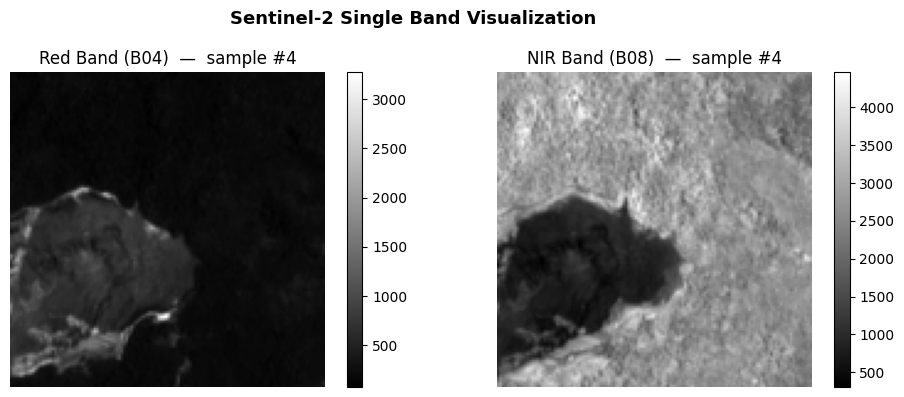

In [11]:
SAMPLE_IDX = 4

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Blue band visualization
arr_blue = h5_file['POST1_B04'][SAMPLE_IDX].squeeze()
im0 = axes[0].imshow(arr_blue, cmap='gray')
axes[0].set_title(f'Red Band (B04)  —  sample #{SAMPLE_IDX}')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# NIR band visualization (highlights vegetation / soil contrast)
arr_nir = h5_file['POST1_B08'][SAMPLE_IDX].squeeze()
im1 = axes[1].imshow(arr_nir, cmap='gray')
axes[1].set_title(f'NIR Band (B08)  —  sample #{SAMPLE_IDX}')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.suptitle('Sentinel-2 Single Band Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Landslide pixels: 3894 / 16384  (23.8%)


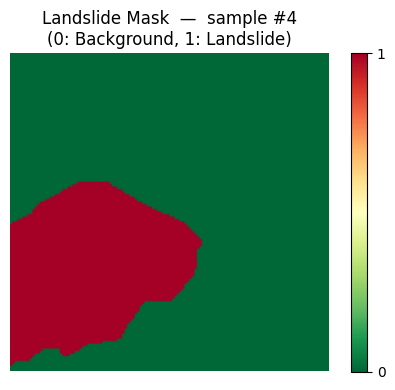

In [12]:
arr_mask = h5_file['None_MASK'][SAMPLE_IDX].squeeze()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(arr_mask, cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_title(f'Landslide Mask  —  sample #{SAMPLE_IDX}\n(0: Background, 1: Landslide)')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, ticks=[0, 1])

landslide_px = int(arr_mask.sum())
total_px     = arr_mask.size
print(f"Landslide pixels: {landslide_px} / {total_px}  ({landslide_px/total_px*100:.1f}%)")
plt.tight_layout()
plt.show()


### 🌈 Multi-band Stack and RGB Composite
Stack 6 bands using `np.concatenate` to create a `(6, 128, 128)` tensor,
then reorder as RGB (Red=B04, Green=B03, Blue=B02) to visualize a color image.

> **Note**: Sentinel-2 pixel values range from 0 to 10000 (reflectance × 10000).
> Normalize with `/ np.max(arr_rgb)` to bring values into [0, 1] for matplotlib display.


In [13]:
BAND_KEYS  = ['POST1_B02','POST1_B03','POST1_B04',
              'POST1_B08','POST1_B11','POST1_B12']
BAND_NAMES = ['Blue (B02)','Green (B03)','Red (B04)',
              'NIR (B08)','SWIR-1 (B11)','SWIR-2 (B12)']

# Stack 6 bands along channel axis (axis=0) -> (6, 128, 128) tensor
arr_post_s2 = np.concatenate(
    [h5_file[key][SAMPLE_IDX] for key in BAND_KEYS], axis=0
)

print(f"Multi-band stack shape : {arr_post_s2.shape}  -> (bands, H, W)")


Multi-band stack shape : (6, 128, 128)  -> (bands, H, W)


In [14]:
arr_label = np.asarray(h5_file['None_MASK'][SAMPLE_IDX], np.float32)

print(f"Label shape    : {arr_label.shape}")
print(f"Unique classes : {np.unique(arr_label)}  (0=background, 1=landslide)")


Label shape    : (1, 128, 128)
Unique classes : [0. 1.]  (0=background, 1=landslide)


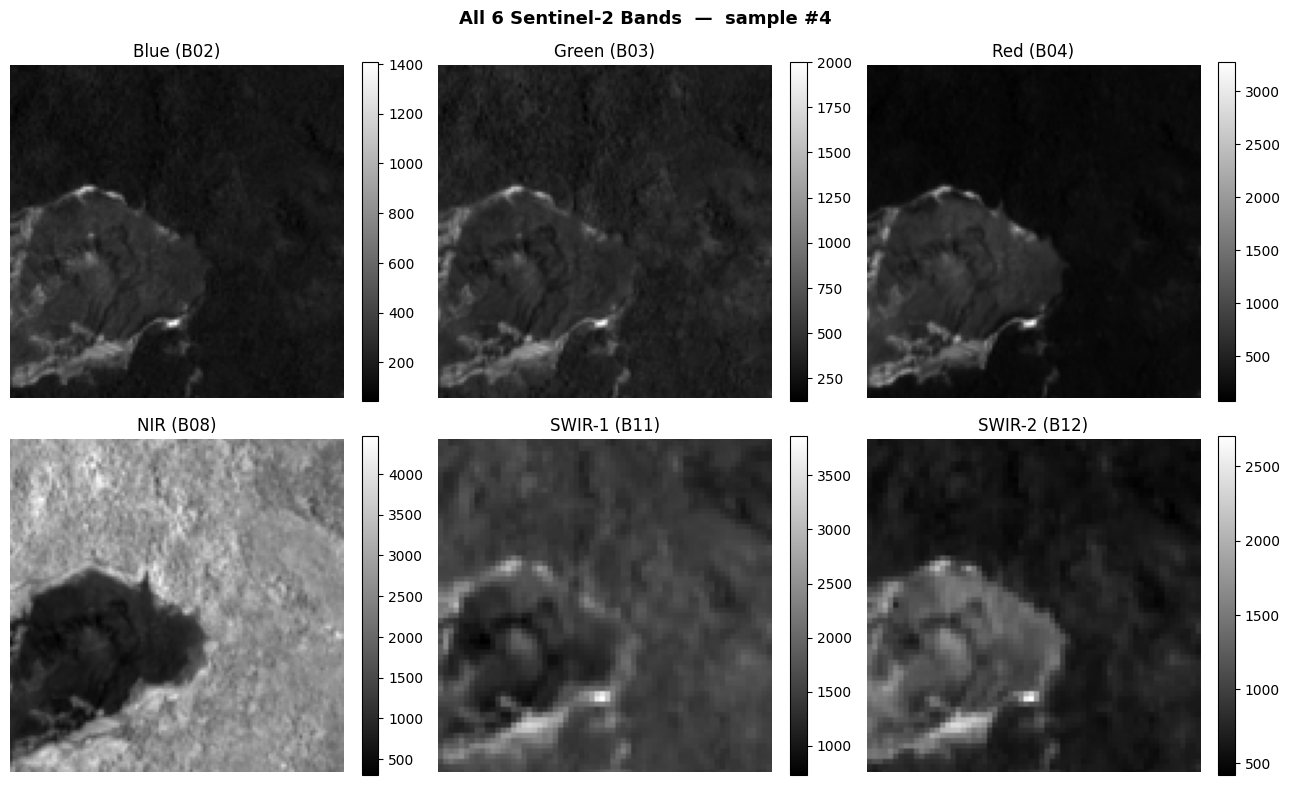

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, (arr, name) in enumerate(zip(arr_post_s2, BAND_NAMES)):
    im = axes[i].imshow(arr, cmap='gray')
    axes[i].set_title(f'{BAND_NAMES[i]}')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle(f'All 6 Sentinel-2 Bands  —  sample #{SAMPLE_IDX}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


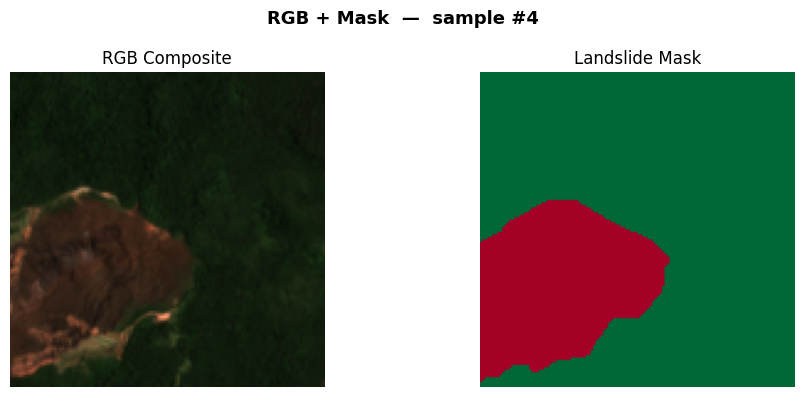

arr_rgb.shape : (128, 128, 3)  ->  (H, W, 3)


In [16]:
# RGB composite: Red=B04(idx2), Green=B03(idx1), Blue=B02(idx0)
arr_rgb = np.dstack((arr_post_s2[2], arr_post_s2[1], arr_post_s2[0]))

# Normalize to [0, 1] (Sentinel-2 DN values range 0-10000)
arr_rgb_norm = arr_rgb / arr_rgb.max()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(arr_rgb_norm)
axes[0].set_title('RGB Composite')
axes[0].axis('off')

axes[1].imshow(arr_label.squeeze(), cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1].set_title('Landslide Mask')
axes[1].axis('off')

plt.suptitle(f'RGB + Mask  —  sample #{SAMPLE_IDX}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"arr_rgb.shape : {arr_rgb.shape}  ->  (H, W, 3)")


---
## Section 3. PyTorch Dataset Class Implementation

### 🎯 Objective
Implement a custom dataset class by inheriting from `torch.utils.data.Dataset`.
This class is required for the DataLoader to supply data in batches.

### Strategy: Why Do We Need a Custom Dataset?
Standard classes like `ImageFolder` are specialized for general images (JPEG/PNG).
Satellite data uses HDF5 format, multiple bands, and float32 — so a custom implementation is needed.

### Key Methods
| Method | Role |
|---|---|
| `__init__` | Open the HDF5 file and save parameters |
| `__len__` | Return total number of samples (rows in the mask array) |
| `__getitem__` | Return image + label by index, apply normalization and transforms |


In [17]:
# ── LandslideRefDataSet — defined in the cell below ──────────────────────────
# Inherits from torch.utils.data.Dataset and implements __init__, __len__,
# and __getitem__ for HDF5-backed, multi-band satellite patch data.


In [18]:
# Mapping: dataset_type string -> HDF5 filename
SPLIT_FILES = {
    'TRAIN' : 'train_n3_s1s2.h5',
    'VALID'  : 'val_n3_s1s2.h5',
    'TEST'   : 'testind_n3_s1s2.h5',
}

# Sentinel-2 post-event band keys (6 channels used as model input)
S2_BAND_KEYS = [
    'POST1_B02',  # Blue   (490 nm)
    'POST1_B03',  # Green  (560 nm)
    'POST1_B04',  # Red    (665 nm)
    'POST1_B08',  # NIR    (832 nm)
    'POST1_B11',  # SWIR-1 (1610 nm)
    'POST1_B12',  # SWIR-2 (2190 nm)
]

class LandslideRefDataSet(data.Dataset):
    """
    Sentinel-2 based landslide detection dataset backed by an HDF5 file.

    Each sample returns:
        image : float32 tensor of shape (C=6, H=128, W=128) — normalised reflectance
        label : float32 array  of shape (H=128, W=128)      — 0=background, 1=landslide

    Args:
        data_dir     : Directory containing the HDF5 split files
        dataset_type : One of 'TRAIN' | 'VALID' | 'TEST'
        mean         : Per-channel mean array (length 6), used for (x - mean) / std
        std          : Per-channel std  array (length 6)
        transform    : Optional callable applied to (image, label) tuple
    """

    def __init__(self, data_dir, dataset_type, mean, std, transform):
        self.mean      = mean
        self.std       = std
        self.transform = transform

        if dataset_type not in SPLIT_FILES:
            raise ValueError(
                f"Invalid dataset_type '{dataset_type}'. "
                f"Choose from {list(SPLIT_FILES.keys())}"
            )

        file_path    = os.path.join(data_dir, SPLIT_FILES[dataset_type])
        self.h5_file = h5py.File(file_path, 'r')

    def __len__(self):
        # First dimension of the mask array equals the total number of patches
        return self.h5_file['None_MASK'].shape[0]

    def __getitem__(self, index):
        # ── Image: stack 6 bands -> (C=6, H, W) ───────────────────────────
        bands  = [self.h5_file[key][index] for key in S2_BAND_KEYS]
        image  = np.asarray(np.concatenate(bands, axis=0), np.float32)
        image  = image / 10000.0                  # DN → reflectance (0–1)

        # ── Label: binary mask ────────────────────────────────────────────
        label  = np.asarray(self.h5_file['None_MASK'][index], np.float32)

        # ── Per-channel z-score normalization: (x − mean) / std ──────────
        for i in range(image.shape[0]):
            image[i] -= self.mean[i]
            image[i] /= self.std[i]

        # ── Optional transforms (augmentation, resize, etc.) ──────────────
        if self.transform:
            image, label = self.transform((image, label))

        return image, label[0]

print("LandslideRefDataSet class defined")


LandslideRefDataSet class defined


### 🧪 Verifying Dataset Behavior
Initialize with `mean=[0]*6`, `std=[1]*6` (no normalization) to confirm the class works correctly.


In [19]:
# Initialize Dataset without normalization (mean=0, std=1) to verify behavior

mean_dummy = [0.0] * 6
std_dummy  = [1.0] * 6

train_dataset = LandslideRefDataSet(
    data_dir     = DATA_DIR,
    dataset_type = 'TRAIN',
    mean         = mean_dummy,
    std          = std_dummy,
    transform    = None,
)
print(f"Dataset created — type: {type(train_dataset)}")


Dataset created — type: <class '__main__.LandslideRefDataSet'>


In [20]:
n_samples = len(train_dataset)
print(f"Total training samples : {n_samples}")


Total training samples : 355


In [21]:
image, label = train_dataset[4]
print(f"image shape : {image.shape}  -> (channels=6, H=128, W=128)")
print(f"label shape : {label.shape}  -> (H=128, W=128)")
print(f"image dtype : {image.dtype}")
print(f"label dtype : {label.dtype}")
print(f"image value range : [{image.min():.3f}, {image.max():.3f}]")
print(f"label unique values : {np.unique(label)}")


image shape : (6, 128, 128)  -> (channels=6, H=128, W=128)
label shape : (128, 128)  -> (H=128, W=128)
image dtype : float32
label dtype : float32
image value range : [0.004, 0.446]
label unique values : [0. 1.]


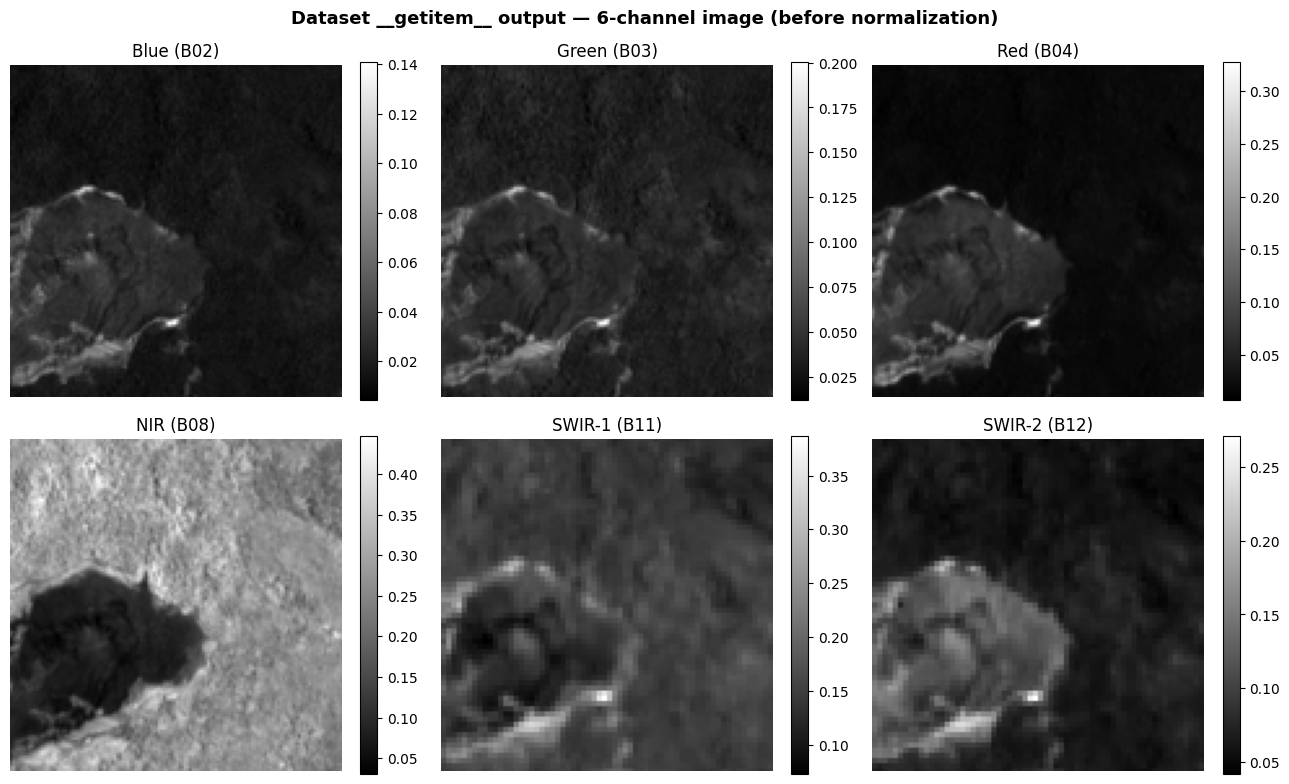

In [22]:
BAND_NAMES = ['Blue (B02)','Green (B03)','Red (B04)',
              'NIR (B08)','SWIR-1 (B11)','SWIR-2 (B12)']

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, (arr, name) in enumerate(zip(image, BAND_NAMES)):
    im = axes[i].imshow(arr, cmap='gray')
    axes[i].set_title(name)
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle('Dataset __getitem__ output — 6-channel image (before normalization)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


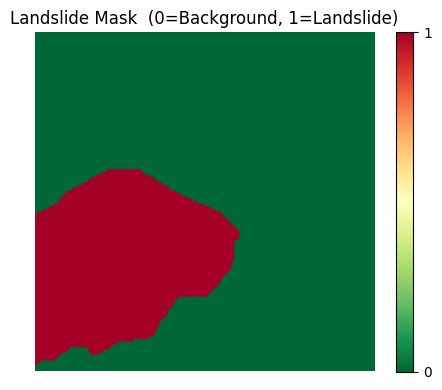

In [23]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(label, cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_title('Landslide Mask  (0=Background, 1=Landslide)')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, ticks=[0, 1])
plt.tight_layout()
plt.show()


---
## Section 4. Computing Per-channel Normalization Statistics

### 🎯 Objective
Iterate over the entire training dataset to compute **per-band mean and standard deviation**.
This ensures all bands are on a similar scale, improving training stability.

### Strategy: 2-Pass Accumulation
Rather than loading everything into memory, we accumulate the running sum (`channels_sum`)
and squared sum (`channels_squared_sum`) over batches, then compute statistics in one pass.

$$\mu = \frac{\sum x}{N}, \quad \sigma = \sqrt{\frac{\sum x^2}{N} - \mu^2}$$

where $N$ is the total number of pixels (samples × 128 × 128).

### Step 1 — Compute raw statistics without normalization


In [24]:
# ── Step 1: Compute raw statistics (mean=0, std=1 → no normalization applied) ─


In [25]:
N_BANDS = 6

# Use mean=0, std=1 -> raw DN/10000 values without normalization
train_dataset_raw = LandslideRefDataSet(
    data_dir=DATA_DIR, dataset_type='TRAIN',
    mean=np.zeros(N_BANDS), std=np.ones(N_BANDS), transform=None
)

# Accumulate per-channel sum and squared sum
channels_sum         = np.zeros(N_BANDS)
channels_squared_sum = np.zeros(N_BANDS)
num_pixels           = 0

for image, _ in tqdm(train_dataset_raw, desc="Computing statistics"):
    channels_sum         += image.sum(axis=(1, 2))
    channels_squared_sum += (image ** 2).sum(axis=(1, 2))
    num_pixels           += image.shape[1] * image.shape[2]

# mu = sum(x) / N,  sigma = sqrt(sum(x^2) / N - mu^2)
mean_raw = channels_sum / num_pixels
std_raw  = np.sqrt(channels_squared_sum / num_pixels - mean_raw ** 2)

print("── Statistics before normalization ─────────────────────────")
for i, (m, s) in enumerate(zip(mean_raw, std_raw)):
    print(f"  Band {i+1}:  mean={m:.6f}  std={s:.6f}")

mean_before_normalization = mean_raw
std_before_normalization  = std_raw


Computing statistics: 100%|██████████| 355/355 [00:00<00:00, 1037.61it/s]

── Statistics before normalization ─────────────────────────
  Band 1:  mean=0.091471  std=0.147504
  Band 2:  mean=0.119801  std=0.142607
  Band 3:  mean=0.111914  std=0.148201
  Band 4:  mean=0.328682  std=0.146885
  Band 5:  mean=0.189942  std=0.081210
  Band 6:  mean=0.121311  std=0.069301


In [26]:
mean_raw


array([0.09147084, 0.1198014 , 0.11191394, 0.32868198, 0.18994196,
       0.12131106])

In [27]:
std_raw


array([0.14750358, 0.14260673, 0.14820109, 0.14688512, 0.08121034,
       0.0693007 ])

### Step 2 — Verify statistics after applying normalization
After normalization, the mean should be close to 0 and the standard deviation close to 1.


In [28]:
# Step 2: Apply precomputed statistics and verify normalization
# After normalization, mean should be ~0 and std should be ~1
mean_precomputed = np.array([0.09147084, 0.1198014 , 0.11191394, 0.32868198, 0.18994196, 0.12131106])
std_precomputed  = np.array([0.14750358, 0.14260673, 0.14820109, 0.14688512, 0.08121034, 0.0693007 ])

train_dataset_normed = LandslideRefDataSet(
    data_dir=DATA_DIR, dataset_type='TRAIN',
    mean=mean_precomputed, std=std_precomputed, transform=None
)

channels_sum         = np.zeros(N_BANDS)
channels_squared_sum = np.zeros(N_BANDS)
num_pixels           = 0

for image, _ in tqdm(train_dataset_normed, desc="Verifying normalization"):
    channels_sum         += image.sum(axis=(1, 2))
    channels_squared_sum += (image ** 2).sum(axis=(1, 2))
    num_pixels           += image.shape[1] * image.shape[2]

mean_normed = channels_sum / num_pixels
std_normed  = np.sqrt(channels_squared_sum / num_pixels - mean_normed ** 2)

print("── Statistics after normalization (mean~0, std~1 expected) ─")
for i, (m, s) in enumerate(zip(mean_normed, std_normed)):
    print(f"  Band {i+1}:  mean={m:+.6f}  std={s:.6f}")

mean_after_normalization = mean_normed
std_after_normalization  = std_normed


Verifying normalization: 100%|██████████| 355/355 [00:00<00:00, 1013.74it/s]

── Statistics after normalization (mean~0, std~1 expected) ─
  Band 1:  mean=+0.000000  std=1.000000
  Band 2:  mean=+0.000000  std=1.000000
  Band 3:  mean=+0.000000  std=1.000000
  Band 4:  mean=-0.000000  std=1.000000
  Band 5:  mean=-0.000000  std=1.000000
  Band 6:  mean=+0.000000  std=1.000000


### 📊 Visualization: Before vs. After Normalization
Compare per-band mean ± std using error bar plots.
Confirm that all band scales become uniform after normalization.


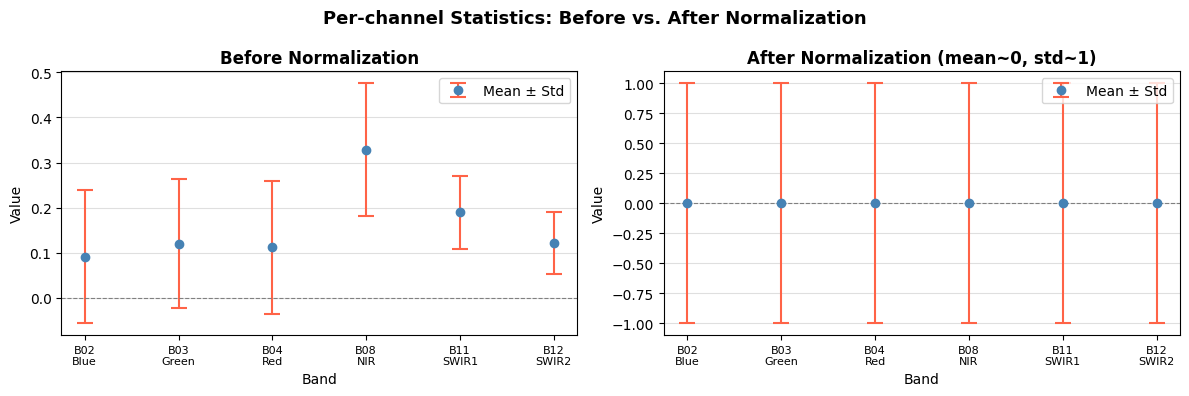

In [29]:
def plot_mean_std(mean_values, std_values, title, ax):
    """Plot per-band mean +/- std as an error bar chart."""
    bands       = np.arange(1, len(mean_values) + 1)
    band_labels = ['B02\nBlue','B03\nGreen','B04\nRed',
                   'B08\nNIR','B11\nSWIR1','B12\nSWIR2']

    ax.errorbar(bands, mean_values, yerr=std_values,
                fmt='o', color='steelblue', ecolor='tomato',
                capsize=6, capthick=1.5, linewidth=1.5,
                label='Mean ± Std')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Band')
    ax.set_ylabel('Value')
    ax.set_xticks(bands)
    ax.set_xticklabels(band_labels, fontsize=8)
    ax.legend()
    ax.grid(axis='y', alpha=0.4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_mean_std(mean_before_normalization, std_before_normalization,
              'Before Normalization', axes[0])
plot_mean_std(mean_after_normalization,  std_after_normalization,
              'After Normalization (mean~0, std~1)', axes[1])

plt.suptitle('Per-channel Statistics: Before vs. After Normalization',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 5. Data Augmentation & Transform Pipeline

### 🎯 Objective
Implement custom Transform classes that apply the **same transformation** to both image and label.

### Strategy: Tuple-based Transforms
Accepts `(image, label)` tuples as input and applies **the same random transformation** to both arrays.
The same flip/rotation must be applied to the label to preserve spatial alignment.

### Implemented Transforms

| Class | Role | Parameter |
|---|---|---|
| `RandomFlipWithLabel` | Random horizontal / vertical flip | `p=0.5` |
| `RandomRotateWithLabel` | Random rotation: 0° / 90° / 180° / 270° | — |
| `ToTensorWithLabel` | NumPy → PyTorch Tensor | — |
| `ResizeWithLabel` | Resize 128×128 → 224×224 (Prithvi input size) | `size=(224,224)` |
| `ToCTHWFormat` | `(C,H,W)` → `(C,T,H,W)` (add time dimension) | `num_frames=1` |

### 💡 Why resize to 224×224?
The Prithvi ViT backbone expects 224×224 patches as its default input.
Images use bilinear interpolation; labels use nearest to prevent label values (0/1) from blending.

### 💡 Why is ToCTHWFormat needed?
Prithvi is a spatiotemporal ViT — its input must be in `(Batch, Channel, Time, H, W)` format.
For single-timestep data, set `num_frames=1` to add the time dimension.


In [30]:
class RandomFlipWithLabel:
    """
    Randomly flip image and label with the same coin flip.

    Shapes expected:
        image : np.ndarray  (C, H, W)
        label : np.ndarray  (H, W)   — output of Dataset.__getitem__ before transform
    """
    def __init__(self, p: float = 0.5):
        self.p = p

    def __call__(self, img_label_tuple):
        image, label = img_label_tuple

        # Horizontal flip (mirror left-right) — W axis
        if random.random() < self.p:
            if isinstance(image, np.ndarray):
                image = np.flip(image, axis=2)   # (C, H, W) → flip W
            if isinstance(label, np.ndarray):
                label = np.flip(label, axis=2)   # (1, H, W) → flip W

        # Vertical flip (mirror up-down) — H axis
        if random.random() < self.p:
            if isinstance(image, np.ndarray):
                image = np.flip(image, axis=1)   # (C, H, W) → flip H
            if isinstance(label, np.ndarray):
                label = np.flip(label, axis=1)   # (1, H, W) → flip H

        return image, label


class RandomRotateWithLabel:
    """
    Randomly rotate image and label by a multiple of 90°.
    k ∈ {0, 1, 2, 3}  →  0°, 90°, 180°, 270° counter-clockwise.

    Shapes expected:
        image : np.ndarray  (C, H, W)
        label : np.ndarray  (H, W)
    """
    def __call__(self, img_label_tuple):
        image, label = img_label_tuple
        k = random.choice([0, 1, 2, 3])

        if k > 0:
            if isinstance(image, np.ndarray):
                image = np.rot90(image, k=k, axes=(1, 2))  # rotate H,W axes of (C,H,W)
            if isinstance(label, np.ndarray):
                label = np.rot90(label, k=k, axes=(1, 2))  # rotate H,W axes of (1,H,W)

        return image, label


class ToTensorWithLabel:
    """Convert (image, label) NumPy arrays to PyTorch Tensors."""    
    def __call__(self, img_label_tuple):
        image, label = img_label_tuple

        if isinstance(image, np.ndarray):
            image = torch.from_numpy(image.copy())
        if isinstance(label, np.ndarray):
            label = torch.from_numpy(label.copy())

        return image, label


class ResizeWithLabel:
    """
    Resize image and label to `size` (H, W).

    Interpolation modes:
        image : bilinear — smooth for continuous reflectance values
        label : nearest  — preserves integer class IDs (no blending)

    Input shapes  (after ToTensorWithLabel):
        image : torch.Tensor  (C, H, W)
        label : torch.Tensor  (H, W)    → unsqueezed to (1, H, W) for F.interpolate
    """
    def __init__(self, size: tuple = (224, 224)):
        self.size = size

    def __call__(self, img_label_tuple):
        image, label = img_label_tuple

        if not isinstance(image, torch.Tensor):
            raise TypeError(f"image must be torch.Tensor, got {type(image)}")
        if not isinstance(label, torch.Tensor):
            raise TypeError(f"label must be torch.Tensor, got {type(label)}")
        if image.ndim != 3:
            raise ValueError(f"image must be (C, H, W), got shape {image.shape}")

        # (C, H, W) → (1, C, H, W) → resize → (C, H, W)
        image = F.interpolate(
            image.unsqueeze(0), size=self.size, mode='bilinear', align_corners=False
        ).squeeze(0)

        # (H, W) → (1, 1, H, W) → resize → (1, H, W) long
        label = F.interpolate(
            label.unsqueeze(0).float(), size=self.size, mode='nearest'
        ).squeeze(0).long()

        return image, label


class ToCTHWFormat:
    """
    Add a time dimension to produce Prithvi's expected (C, T, H, W) format.

    Single-timestep (num_frames=1):
        (C, H, W) → (C, 1, H, W)

    Multi-timestep (num_frames=T):
        Assumes channels are stacked as [band_1_t1, band_1_t2, ..., band_B_t1, band_B_t2, ...]
        (C=B*T, H, W) → (B, T, H, W)
    """
    def __init__(self, num_frames: int = 1):
        self.num_frames = num_frames

    def __call__(self, img_label_tuple):
        image, label = img_label_tuple

        if not isinstance(image, torch.Tensor):
            raise TypeError(f"image must be torch.Tensor, got {type(image)}")

        C, H, W = image.shape

        if self.num_frames == 1:
            image = image.unsqueeze(1)            # (C, H, W) → (C, 1, H, W)
        else:
            if C % self.num_frames != 0:
                raise ValueError(
                    f"Channel count C={C} must be divisible by num_frames={self.num_frames}."
                )
            B = C // self.num_frames
            # (C, H, W) → (T, B, H, W) → (B, T, H, W)
            image = image.reshape(self.num_frames, B, H, W).permute(1, 0, 2, 3)

        return image, label

print("Transform classes defined:")
print("  RandomFlipWithLabel   RandomRotateWithLabel   ToTensorWithLabel")
print("  ResizeWithLabel       ToCTHWFormat")


Transform classes defined:
  RandomFlipWithLabel   RandomRotateWithLabel   ToTensorWithLabel
  ResizeWithLabel       ToCTHWFormat


In [31]:
# Training transform: Augmentation (Flip + Rotate) -> Tensor -> Resize -> CTHW
transform_train = transforms.Compose([
    RandomFlipWithLabel(p=0.5),   # Random horizontal / vertical flip
    RandomRotateWithLabel(),       # Random 90-degree rotation
    ToTensorWithLabel(),           # NumPy -> Tensor
    ResizeWithLabel((224, 224)),   # 128x128 -> 224x224 (Prithvi input size)
    ToCTHWFormat(num_frames=1),    # (C,H,W) -> (C,1,H,W)
])

# Validation / test transform: conversion only, no augmentation
transform_valtest = transforms.Compose([
    ToTensorWithLabel(),
    ResizeWithLabel((224, 224)),
    ToCTHWFormat(num_frames=1),
])

print("Train transform    :", transform_train)
print("\nVal/Test transform :", transform_valtest)


Train transform    : Compose(
)

Val/Test transform : Compose(
)


---
## Section 6. Dataset & DataLoader Initialization

### 🎯 Objective
Initialize Train / Validation datasets and DataLoaders using the final mean/std values and transform pipeline.

### DataLoader Parameter Explanation

| Parameter | Train | Validation | Reason |
|---|---|---|---|
| `batch_size` | 8 | 1 | Training uses batches; validation runs sample-by-sample |
| `shuffle` | True | False | Randomize training order; fix validation order |
| `num_workers` | 4 | 4 | Parallel data loading |
| `pin_memory` | True | True | Speeds up CPU→GPU transfer |
| `drop_last` | True | False | Drop incomplete last batch for consistent batch sizes |


In [32]:
# Per-channel mean/std computed in Section 4 (based on DN/10000)
MEAN = np.array([0.09147084, 0.1198014 , 0.11191394, 0.32868198, 0.18994196, 0.12131106])
STD  = np.array([0.14750358, 0.14260673, 0.14820109, 0.14688512, 0.08121034, 0.0693007 ])

train_dataset = LandslideRefDataSet(
    data_dir=DATA_DIR, dataset_type='TRAIN',
    mean=MEAN, std=STD, transform=transform_train
)
valid_dataset = LandslideRefDataSet(
    data_dir=DATA_DIR, dataset_type='VALID',
    mean=MEAN, std=STD, transform=transform_valtest
)

print(f"Train samples : {len(train_dataset):>4d}")
print(f"Valid samples : {len(valid_dataset):>4d}")


Train samples :  355
Valid samples :   88


### 🔍 Verifying Data Augmentation
Repeat this cell multiple times to verify that data augmentation is being applied to the training data.

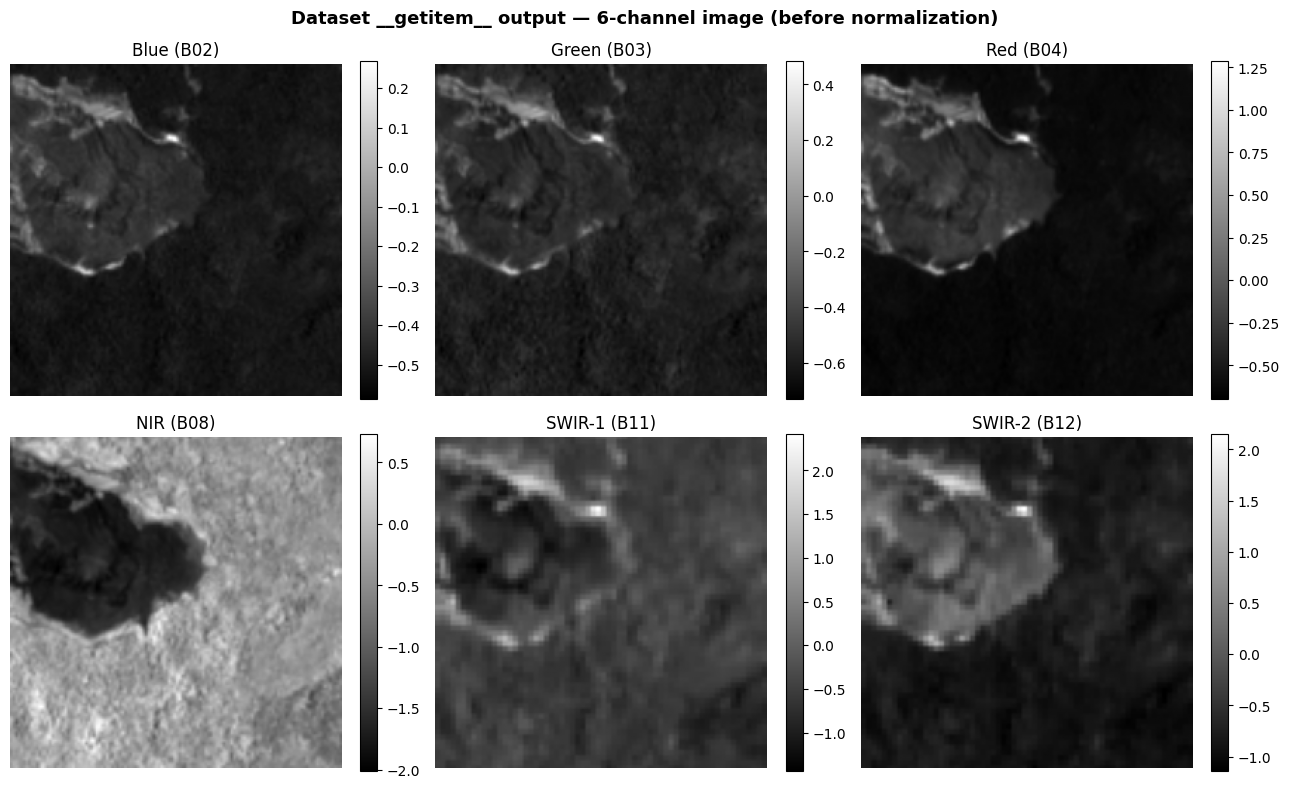

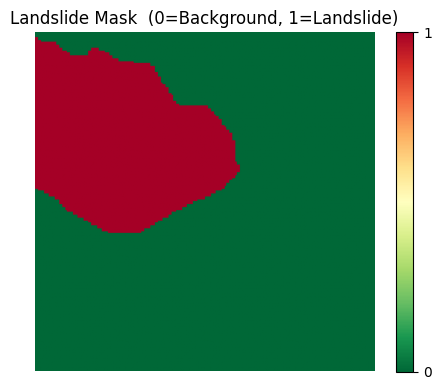

In [33]:
image, label = train_dataset[4]

image_np = image.squeeze(1).cpu().numpy()  # (6, 224, 224)
label_np = label.cpu().numpy()               # (224, 224)

# 6 bands
BAND_NAMES = ['Blue (B02)','Green (B03)','Red (B04)',
              'NIR (B08)','SWIR-1 (B11)','SWIR-2 (B12)']

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, (arr, name) in enumerate(zip(image_np, BAND_NAMES)):
    im = axes[i].imshow(arr, cmap='gray')
    axes[i].set_title(name)
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle('Dataset __getitem__ output — 6-channel image (before normalization)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# label
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(label, cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_title('Landslide Mask  (0=Background, 1=Landslide)')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, ticks=[0, 1])
plt.tight_layout()
plt.show()


In [34]:
train_loader = DataLoader(
    train_dataset,
    batch_size  = 8,
    shuffle     = True,   # Shuffle order every epoch
    num_workers = 4,      # Parallel data loading workers
    pin_memory  = True,   # Speed up CPU->GPU transfer
    drop_last   = True,   # Drop incomplete last batch for consistent batch sizes
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size  = 1,
    shuffle     = False,  # Fixed order for validation
    num_workers = 4,
    pin_memory  = True,
)

print(f"Train batches : {len(train_loader)}  ({len(train_dataset)} / 8 = {len(train_dataset)/8:.1f})")
print(f"Valid batches : {len(valid_loader)}  ({len(valid_dataset)} / 1 = {len(valid_dataset)/1:.1f})")


Train batches : 44  (355 / 8 = 44.4)
Valid batches : 88  (88 / 1 = 88.0)


In [35]:
# Load one sample with the full transform pipeline to verify output shapes
idx = 0
x, y = train_dataset[idx]


### 🔍 Verifying Final Tensor Shapes
Check the shapes after applying the full transform pipeline.
- `x.shape` → `(6, 1, 224, 224)` : (channels, time, H, W) ← Prithvi input format
- `y.shape` → `(224, 224)` : per-pixel class index (0 or 1)


In [36]:
print(f"x.shape : {x.shape}")
print(f"  -> (Channel={x.shape[0]}, Time={x.shape[1]}, H={x.shape[2]}, W={x.shape[3]})")
print(f"  -> Prithvi input format (C, T, H, W)")


x.shape : torch.Size([6, 1, 224, 224])
  -> (Channel=6, Time=1, H=224, W=224)
  -> Prithvi input format (C, T, H, W)


In [37]:
print(f"y.shape : {y.shape}")
print(f"  -> (H={y.shape[0]}, W={y.shape[1]})")
print(f"  -> Per-pixel class index (0=background, 1=landslide)")
print(f"  y.dtype : {y.dtype}  (required: long for CrossEntropy / DiceLoss)")


y.shape : torch.Size([224, 224])
  -> (H=224, W=224)
  -> Per-pixel class index (0=background, 1=landslide)
  y.dtype : torch.int64  (required: long for CrossEntropy / DiceLoss)


In [38]:
# Dataset and DataLoader are ready.
# Proceed to Section 7 to build the Prithvi + UNet segmentation model.


---
## Section 7. Building the Prithvi (encoder) + UNet (decoder) Model

### 🎯 Objective
Use **TerraTorch**'s `EncoderDecoderFactory` to build a segmentation model
with a Prithvi ViT Encoder and a UNet Decoder.

### Strategy: Geospatial Foundation Model Fine-tuning
Instead of training from scratch, we initialize the encoder with pretrained weights 
from NASA-IBM’s Prithvi model and train the entire network end-to-end for the landslide 
detection task, enabling effective learning with limited labeled data.

```
Input (6, 1, 224, 224)
       ↓
Prithvi ViT Encoder  ← Pre-trained weights (frozen or fine-tuned)
       ↓
UNet Decoder         ← Task-specific decoderr (training target)
       ↓
Output (2, 224, 224) ← Per-class logits (background / landslide)
```

### YAML Configuration File
Model architecture configurations (backbone, head, num_classes, etc.) are defined in
`config_prithvi300_UNet.yaml`.
Separating code from configuration allows model changes without modifying code.


In [39]:
# Load YAML config
with open(CONFIG_FILE, 'r') as f:
    config = yaml.safe_load(f)

model_args = dict(config["model"]["model_args"])

if BACKBONE_CKPT_PATH is not None:
    if not os.path.exists(BACKBONE_CKPT_PATH):
        raise FileNotFoundError(
            f"Could not find Prithvi checkpoint at {BACKBONE_CKPT_PATH}. "
            "Download Prithvi_EO_V2_300M.pt or update BACKBONE_CKPT_PATH. "
            "Set BACKBONE_CKPT_PATH = None only if you do not want to load a local checkpoint."
        )
    model_args["backbone_ckpt_path"] = BACKBONE_CKPT_PATH
else:
    model_args.pop("backbone_ckpt_path", None)

print("── Model configuration ───────────────────────────────────────")
for k, v in model_args.items():
    print(f"  {k:30s} : {v}")


── Model configuration ───────────────────────────────────────
  backbone_pretrained            : True
  backbone                       : prithvi_eo_v2_300
  backbone_bands                 : ['BLUE', 'GREEN', 'RED', 'NIR_NARROW', 'SWIR_1', 'SWIR_2']
  backbone_num_frames            : 1
  necks                          : [{'name': 'SelectIndices', 'indices': [5, 11, 17, 23]}, {'name': 'ReshapeTokensToImage', 'effective_time_dim': 1}, {'name': 'LearnedInterpolateToPyramidal'}]
  decoder                        : UNetDecoder
  decoder_channels               : [512, 256, 128, 64]
  num_classes                    : 2
  backbone_ckpt_path             : /workspace/chiayu/projects/geofm-workshop/workshop_materials/checkpoints/Prithvi_EO_V2_300M.pt


In [40]:
# Build model using TerraTorch EncoderDecoderFactory
# Ref: https://github.com/terrastackai/terratorch/blob/main/terratorch/models/encoder_decoder_factory.py
factory = EncoderDecoderFactory()
model   = factory.build_model(task='segmentation', **model_args)

print(f"Model built successfully")
print(f"  Model type : {type(model).__name__}")


2026-05-15 18:34:42,572 - INFO - Loaded weights for HLSBands.BLUE in position 0 of patch embed
2026-05-15 18:34:42,574 - INFO - Loaded weights for HLSBands.GREEN in position 1 of patch embed
2026-05-15 18:34:42,575 - INFO - Loaded weights for HLSBands.RED in position 2 of patch embed
2026-05-15 18:34:42,575 - INFO - Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
2026-05-15 18:34:42,575 - INFO - Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
2026-05-15 18:34:42,576 - INFO - Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed


Model built successfully
  Model type : PixelWiseModel


### 🔍 Model Architecture and Parameter Count


In [41]:
# Print full model architecture (Encoder + Decoder)
print(model)


PixelWiseModel(
  (encoder): PrithviViT(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(6, 1024, kernel_size=(1, 16, 16), stride=(1, 16, 16))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-23): 24 x Block(
        (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): Attention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (act): GELU(approximate='none')
          (drop1): Dropout(p=0.0

In [42]:
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"Total parameters     : {total_params:>12,}")
print(f"Trainable parameters : {trainable_params:>12,}  ({trainable_params/total_params*100:.1f}%)")
print(f"Frozen parameters    : {frozen_params:>12,}  ({frozen_params/total_params*100:.1f}%)")


Total parameters     :  324,204,674
Trainable parameters :  324,204,674  (100.0%)
Frozen parameters    :            0  (0.0%)


In [43]:
encoder_params = sum(p.numel() for p in model.encoder.parameters())
neck_params = sum(p.numel() for p in model.neck.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())
head_params = sum(p.numel() for p in model.head.parameters())

encoder_trainable = sum(p.numel() for p in model.encoder.parameters() if p.requires_grad)
neck_trainable = sum(p.numel() for p in model.neck.parameters() if p.requires_grad)
decoder_trainable = sum(p.numel() for p in model.decoder.parameters() if p.requires_grad)
head_trainable = sum(p.numel() for p in model.head.parameters() if p.requires_grad)

print("\nPrithvi Encoder")
print(f"Total     : {encoder_params:>12,}  ({encoder_params/total_params*100:.1f}%)")
print(f"Trainable : {encoder_trainable:>12,}  ({encoder_trainable/total_params*100:.1f}%)")

print("\nNeck")
print(f"Total     : {neck_params:>12,}  ({neck_params/total_params*100:.1f}%)")
print(f"Trainable : {neck_trainable:>12,}  ({neck_trainable/total_params*100:.1f}%)")

print("\nU-Net Decoder")
print(f"Total     : {decoder_params:>12,}  ({decoder_params/total_params*100:.1f}%)")
print(f"Trainable : {decoder_trainable:>12,}  ({decoder_trainable/total_params*100:.1f}%)")

print("\nSegmentation Head")
print(f"Total     : {head_params:>12,}  ({head_params/total_params*100:.1f}%)")
print(f"Trainable : {head_trainable:>12,}  ({head_trainable/total_params*100:.1f}%)")



Prithvi Encoder
Total     :  303,886,336  (93.7%)
Trainable :  303,886,336  (93.7%)

Neck
Total     :    4,720,896  (1.5%)
Trainable :    4,720,896  (1.5%)

U-Net Decoder
Total     :   15,597,312  (4.8%)
Trainable :   15,597,312  (4.8%)

Segmentation Head
Total     :          130  (0.0%)
Trainable :          130  (0.0%)


In [44]:
# verify sum of weights
324204674 == (303886336 + 4720896 + 15597312 + 130)


True

In [45]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)

print(f"Device : {device.upper()}")
if device == "cuda":
    print(f"  GPU model  : {torch.cuda.get_device_name(0)}")
    print(f"  GPU memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device : CUDA
  GPU model  : NVIDIA RTX PRO 6000 Blackwell Server Edition
  GPU memory : 102.0 GB


---
## Section 8. Optimizer & Loss Function

### 🎯 Objective
Define the optimizer and loss function for training.

### Optimizer: Adam
- `lr=1e-5` : A small learning rate is critical when fine-tuning pre-trained models.
  A large learning rate can destroy the good feature representations learned during pre-training.
- `weight_decay=0.0` : No L2 regularization

### Loss Function: Dice Loss
Effective for segmentation tasks with severe class imbalance (landslide pixels << background pixels).

$$\mathcal{L}_{Dice} = 1 - \frac{2|P \cap G|}{|P| + |G|}$$

- `mode='multiclass'` : Multi-class classification (background=0, landslide=1)
- `from_logits=True` : Model output is raw logits before softmax
- `ignore_index=255` : Pixels with label 255 are excluded from training (boundary / uncertain regions)


In [46]:
# Optimizer: Adam (small lr for fine-tuning)
optimizer = optim.Adam(
    model.parameters(),
    lr           = 1e-5,   # Small lr for fine-tuning pre-trained model
    weight_decay = 0.0,    # No L2 regularization
)

# Loss function: Dice Loss (robust to class imbalance)
loss_fn = DiceLoss(
    mode         = 'multiclass',  # Multi-class segmentation
    classes      = None,          # Use all classes
    log_loss     = False,
    from_logits  = True,          # Model output is raw logits (before softmax)
    smooth       = 0.0,
    ignore_index = 255,           # Exclude pixels with label 255 from loss
    eps          = 1e-7,          # Numerical stability (prevent division by zero)
)

print(f"Optimizer : {type(optimizer).__name__}  (lr={optimizer.param_groups[0]['lr']})")
print(f"Loss fn   : {type(loss_fn).__name__}  (mode=multiclass, ignore_index=255)")


Optimizer : Adam  (lr=1e-05)
Loss fn   : DiceLoss  (mode=multiclass, ignore_index=255)


---
## Section 9. Evaluation Function (eval_image)

### 🎯 Objective
Define a function that computes TP/FP/TN/FN by comparing predictions and labels.
These values are used to calculate segmentation metrics: Precision, Recall, F1, IoU.

### Confusion Matrix

|  | Predicted: Landslide | Predicted: Background |
|---|---|---|
| **Actual: Landslide** | TP | FN |
| **Actual: Background** | FP | TN |

### Derived Metrics

$$Precision = \frac{TP}{TP+FP}, \quad Recall = \frac{TP}{TP+FN}$$

$$F1 = \frac{2 \cdot P \cdot R}{P + R}, \quad IoU = \frac{TP}{TP+FP+FN}$$

> **Handling `ignore_index`**: `np.where((label>=0) & (label<num_classes))`
> excludes invalid labels (e.g., 255) from evaluation.


In [47]:
def eval_image(predict: np.ndarray,
               label:   np.ndarray,
               num_classes: int):
    """
    Compute per-class TP/FP/TN/FN from pixel-wise predictions and ground truth labels.

    Args:
        predict     : Predicted class array (1D, values in 0..num_classes-1)
        label       : Ground truth label array (1D, values in 0..num_classes-1; 255=ignore)
        num_classes : Number of classes

    Returns:
        TP, FP, TN, FN : Each with shape (num_classes, 1)
        n_valid        : Number of valid pixels
    """
    # Select only valid label range (exclude ignore_index such as 255)
    valid_mask = (label >= 0) & (label < num_classes)
    predict    = predict[valid_mask]
    label      = label[valid_mask]

    TP = np.zeros((num_classes, 1))
    FP = np.zeros((num_classes, 1))
    TN = np.zeros((num_classes, 1))
    FN = np.zeros((num_classes, 1))

    for i in range(num_classes):
        pred_pos  = (predict == i)   # Predicted as class i
        pred_neg  = (predict != i)   # Not predicted as class i
        label_pos = (label   == i)   # Actually class i

        TP[i] = np.sum( pred_pos &  label_pos)
        FP[i] = np.sum( pred_pos & ~label_pos)
        TN[i] = np.sum( pred_neg & ~label_pos)
        FN[i] = np.sum( pred_neg &  label_pos)

    return TP, FP, TN, FN, len(label)

print("eval_image function defined")


eval_image function defined


---
## Section 10. Training Loop (Train & Validation)

### 🎯 Objective
Train the model for 50 epochs, evaluate validation performance each epoch,
and save a checkpoint of the best-performing model.

### Strategy: Checkpoint Based on Best Validation Loss
The checkpoint is only updated when `val_loss < best_loss`.
Even if overfitting starts, the model with the best generalization performance is preserved.

### Training Loop Flow

**Train phase:**
```
model.train()
for batch in train_loader:
    1. Move data to GPU
    2. Forward pass → compute logits
    3. Compute Dice Loss
    4. Backward pass (backpropagation)
    5. optimizer.step() (update parameters)
```

**Validation phase:**
```
model.eval()
with torch.no_grad():  # Disable gradient computation
    for batch in valid_loader:
        1. Forward pass
        2. softmax → argmax → predicted class
        3. Accumulate TP/FP/TN/FN
        4. Compute Precision, Recall, F1, IoU
```

### 💡 Handling Prithvi Output
```python
output = result.output if is_dataclass(result) and hasattr(result, "output") else result
```
TerraTorch models return a dataclass with an `output` attribute,
so we distinguish it from a plain tensor.

### 📁 Saving the Checkpoint
After training, save the model weights with `torch.save(checkpoint, path)`.


In [48]:
# ── Training configuration ──────────────────────────────────────────────────
NUM_EPOCHS     = 50
NUM_CLASSES    = 2         # 0: background, 1: landslide
EPSILON        = 1e-7     # Prevent division by zero in metric computation
LANDSLIDE_CLS  = 1         # Landslide class index
# TRAINING_CHECKPOINT_PATH is defined in the path setup cell.

# ── Initialize tracking variables ───────────────────────────────────────────
best_loss      = np.inf
checkpoint     = None
scalar_history = {k: [] for k in [
    'Training-Loss',
    'Validation-Loss',
    'Validation-Precision',
    'Validation-Recall',
    'Validation-F1score',
    'Validation-IoU',
    'Validation-mF1score',
    'Validation-mIoU',
    'Validation-mAcc',
]}

# ── Training loop ────────────────────────────────────────────────────────────
for epoch in range(NUM_EPOCHS):

    # ════════════════════════════════════════════
    # TRAIN
    # ════════════════════════════════════════════
    model.train()
    train_loss      = 0.0
    n_train_samples = 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train")

    for x, y in loop:
        x = x.float().to(device)
        y = y.long().to(device)

        optimizer.zero_grad()

        # Forward pass
        result = model.forward(x)
        output = result.output if is_dataclass(result) and hasattr(result, "output") else result

        # Compute loss and backpropagate
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        # Accumulate weighted loss (weighted by batch size)
        batch_size       = x.size(0)
        train_loss      += loss.item() * batch_size
        n_train_samples += batch_size

        loop.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = train_loss / n_train_samples
    scalar_history['Training-Loss'].append(train_loss)
    print(f"  Train Loss      : {train_loss:.6f}")

    # ════════════════════════════════════════════
    # VALIDATION
    # ════════════════════════════════════════════
    model.eval()
    val_loss      = 0.0
    n_val_samples = 0

    TP_all = np.zeros((NUM_CLASSES, 1))
    FP_all = np.zeros((NUM_CLASSES, 1))
    TN_all = np.zeros((NUM_CLASSES, 1))
    FN_all = np.zeros((NUM_CLASSES, 1))

    for x, y in valid_loader:
        x = x.float().to(device)
        y = y.long().to(device)

        with torch.no_grad():
            result = model.forward(x)
        output = result.output if is_dataclass(result) and hasattr(result, "output") else result

        loss = loss_fn(output, y)

        # Argmax -> predicted class
        _, pred  = torch.max(nn.functional.softmax(output, dim=1).detach(), dim=1)
        pred_np  = pred.squeeze().cpu().numpy()
        label_np = y.squeeze().cpu().numpy()

        # Accumulate TP/FP/TN/FN
        TP, FP, TN, FN, _ = eval_image(pred_np.reshape(-1), label_np.reshape(-1), NUM_CLASSES)
        TP_all += TP
        FP_all += FP
        TN_all += TN
        FN_all += FN

        batch_size     = x.size(0)
        val_loss      += loss.item() * batch_size
        n_val_samples += batch_size

    val_loss = val_loss / n_val_samples
    scalar_history['Validation-Loss'].append(val_loss)
    print(f"  Validation Loss : {val_loss:.6f}")

    # ════════════════════════════════════════════
    # SAVE BEST MODEL
    # ════════════════════════════════════════════
    if val_loss < best_loss:
        best_loss  = val_loss
        checkpoint = {"model": copy.deepcopy(model.state_dict())}

        # Compute per-class metrics
        P   = TP_all / (TP_all + FP_all + EPSILON)
        R   = TP_all / (TP_all + FN_all + EPSILON)
        F1  = 2 * P * R / (P + R + EPSILON)
        IoU = TP_all / (TP_all + FP_all + FN_all + EPSILON)
        Acc = (TP_all + TN_all) / (TP_all + FP_all + FN_all + TN_all + EPSILON)

        mF1  = float(np.mean(F1))
        mIoU = float(np.mean(IoU))
        mAcc = float(np.mean(Acc))

        print(f"  Best model updated at epoch {epoch+1}")
        print(f"    Precision : {P[LANDSLIDE_CLS][0]:.4f}")
        print(f"    Recall    : {R[LANDSLIDE_CLS][0]:.4f}")
        print(f"    F1 Score  : {F1[LANDSLIDE_CLS][0]:.4f}")
        print(f"    IoU       : {IoU[LANDSLIDE_CLS][0]:.4f}")
        print(f"    mF1 : {mF1:.4f}  mIoU : {mIoU:.4f}  mAcc : {mAcc:.4f}")

        scalar_history['Validation-Precision'].append(P[LANDSLIDE_CLS][0])
        scalar_history['Validation-Recall'].append(R[LANDSLIDE_CLS][0])
        scalar_history['Validation-F1score'].append(F1[LANDSLIDE_CLS][0])
        scalar_history['Validation-IoU'].append(IoU[LANDSLIDE_CLS][0])
        scalar_history['Validation-mF1score'].append(mF1)
        scalar_history['Validation-mIoU'].append(mIoU)
        scalar_history['Validation-mAcc'].append(mAcc)

    model.train()

# ── Save checkpoint ──────────────────────────────────────────────────────────
save_path = TRAINING_CHECKPOINT_PATH
torch.save(checkpoint, save_path)
print(f"\nCheckpoint saved -> {save_path}")


Epoch [1/50] Train: 100%|██████████| 44/44 [00:04<00:00, 10.95it/s, loss=0.5415]

  Train Loss      : 0.524599


  Validation Loss : 0.512022
  Best model updated at epoch 1
    Precision : 0.3416
    Recall    : 0.9787
    F1 Score  : 0.5064
    IoU       : 0.3391
    mF1 : 0.6882  mIoU : 0.5545  mAcc : 0.7942


Epoch [2/50] Train: 100%|██████████| 44/44 [00:03<00:00, 14.45it/s, loss=0.3622]

  Train Loss      : 0.432039


...

  Train Loss      : 0.202418


  Validation Loss : 0.295871
  Best model updated at epoch 49
    Precision : 0.9095
    Recall    : 0.9828
    F1 Score  : 0.9448
    IoU       : 0.8953
    mF1 : 0.9689  mIoU : 0.9407  mAcc : 0.9876


Epoch [50/50] Train: 100%|██████████| 44/44 [00:05<00:00,  8.13it/s, loss=0.2474]

  Train Loss      : 0.203554


  Validation Loss : 0.292781
  Best model updated at epoch 50
    Precision : 0.9180
    Recall    : 0.9786
    F1 Score  : 0.9473
    IoU       : 0.8999
    mF1 : 0.9703  mIoU : 0.9434  mAcc : 0.9883

Checkpoint saved -> /workspace/chiayu/projects/geofm-workshop/workshop_materials/prithvi_unet_landslide_best.pt


---
## Section 11. Training Result Visualization

### 🎯 Objective
Visualize the training and validation loss curves to analyze the learning process.

### Interpretation Guide
- **Both curves decreasing together**: Normal, healthy training
- **Train loss ↓, Val loss ↑**: Overfitting → consider early stopping or regularization
- **Red dot**: Epoch with the lowest validation loss → location of the saved checkpoint


In [49]:
# Summarize training and validation loss history as a DataFrame
df_loss = pd.DataFrame({
    "epoch"           : range(1, NUM_EPOCHS + 1),
    "training_loss"   : scalar_history["Training-Loss"],
    "validation_loss" : scalar_history["Validation-Loss"],
})
df_loss = df_loss.set_index("epoch")
df_loss.tail(5)


,training_loss,validation_loss
epoch,,
46,0.215561,0.300344
47,0.205293,0.300074
48,0.207317,0.298211
49,0.202418,0.295871
50,0.203554,0.292781


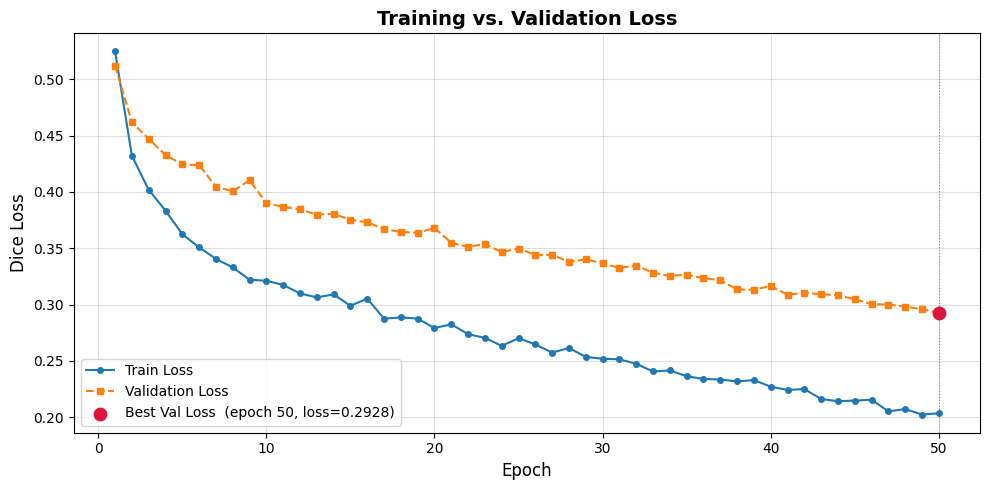


Best Validation Loss : 0.292781  (epoch 50)


In [50]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_loss.index, df_loss['training_loss'],
        marker='o', markersize=4, linestyle='-',  label='Train Loss')
ax.plot(df_loss.index, df_loss['validation_loss'],
        marker='s', markersize=4, linestyle='--', label='Validation Loss')

# Highlight best epoch
best_epoch = int(df_loss['validation_loss'].idxmin())
best_val   = df_loss.loc[best_epoch, 'validation_loss']
ax.scatter(best_epoch, best_val, color='crimson', zorder=5,
           s=80, label=f'Best Val Loss  (epoch {best_epoch}, loss={best_val:.4f})')
ax.axvline(best_epoch, color='crimson', linestyle=':', linewidth=0.8, alpha=0.6)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Dice Loss', fontsize=12)
ax.set_title('Training vs. Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nBest Validation Loss : {best_val:.6f}  (epoch {best_epoch})")


### 🔧 Evaluation Utility: `evaluation()`
Before running the test set, we define a reusable `evaluation()` function.
It wraps the same inference + metric logic used in the validation phase of the training loop,
so results are directly comparable.

In [51]:
def evaluation(loader, model, loss_fn,
               num_classes: int = 2,
               epsilon:     float = 1e-7):
    """
    Run full-dataset inference and compute segmentation metrics.

    Mirrors the validation block inside the training loop so that metrics
    computed here are directly comparable to per-epoch validation scores.

    Args:
        loader      : DataLoader — batch_size=1 is recommended for evaluation
        model       : Trained segmentation model (TerraTorch EncoderDecoder)
        loss_fn     : Loss function identical to the one used during training
        num_classes : Number of output classes (default: 2)
        epsilon     : Small constant for numerical stability (default: 1e-7)

    Returns:
        dict with keys:
            'Loss', 'Precision', 'Recall', 'F1score', 'IoU',
            'mF1score', 'mIoU', 'mAcc'
    """
    model.eval()

    # ── Confusion-matrix accumulators (across entire dataset) ──────────
    TP_all = np.zeros((num_classes, 1))
    FP_all = np.zeros((num_classes, 1))
    TN_all = np.zeros((num_classes, 1))
    FN_all = np.zeros((num_classes, 1))

    total_loss = 0.0
    n_samples  = 0

    for x, y in tqdm(loader, desc='Evaluating'):
        x = x.float().to(device)
        y = y.long().to(device)

        # Forward pass — no gradient needed
        with torch.no_grad():
            result = model.forward(x)

        # Unwrap TerraTorch dataclass output (same pattern as training loop)
        output = result.output if is_dataclass(result) and hasattr(result, 'output') else result

        loss = loss_fn(output, y)

        # softmax → argmax → predicted class map
        _, pred  = torch.max(nn.functional.softmax(output, dim=1).detach(), dim=1)
        pred_np  = pred.squeeze().cpu().numpy()
        label_np = y.squeeze().cpu().numpy()

        TP, FP, TN, FN, _ = eval_image(
            pred_np.reshape(-1), label_np.reshape(-1), num_classes
        )
        TP_all += TP
        FP_all += FP
        TN_all += TN
        FN_all += FN

        batch_size  = x.size(0)
        total_loss += loss.item() * batch_size
        n_samples  += batch_size

    # ── Per-class metrics ──────────────────────────────────────────────
    avg_loss = total_loss / n_samples

    P   = np.zeros((num_classes, 1))
    R   = np.zeros((num_classes, 1))
    F1  = np.zeros((num_classes, 1))
    IoU = np.zeros((num_classes, 1))
    Acc = np.zeros((num_classes, 1))

    for i in range(num_classes):
        P[i]   = TP_all[i] / (TP_all[i] + FP_all[i] + epsilon)
        R[i]   = TP_all[i] / (TP_all[i] + FN_all[i] + epsilon)
        F1[i]  = 2.0 * P[i] * R[i] / (P[i] + R[i] + epsilon)
        IoU[i] = TP_all[i] / (TP_all[i] + FP_all[i] + FN_all[i] + epsilon)
        Acc[i] = (TP_all[i] + TN_all[i]) / (
                  TP_all[i] + FP_all[i] + FN_all[i] + TN_all[i] + epsilon)

    mF1  = float(np.mean(F1))
    mIoU = float(np.mean(IoU))
    mAcc = float(np.mean(Acc))

    cls = 1   # Landslide class index

    # ── Print results ──────────────────────────────────────────────────
    print(f"── Evaluation Results ───────────────────────────────────────")
    print(f"  Loss      : {avg_loss:.6f}")
    print(f"  Precision : {P[cls][0]:.4f}")
    print(f"  Recall    : {R[cls][0]:.4f}")
    print(f"  F1 Score  : {F1[cls][0]:.4f}")
    print(f"  IoU       : {IoU[cls][0]:.4f}")
    print(f"  mF1       : {mF1:.4f}    mIoU : {mIoU:.4f}    mAcc : {mAcc:.4f}")

    model.train()

    return {
        'Loss'      : avg_loss,
        'Precision' : P[cls][0],
        'Recall'    : R[cls][0],
        'F1score'   : F1[cls][0],
        'IoU'       : IoU[cls][0],
        'mF1score'  : mF1,
        'mIoU'      : mIoU,
        'mAcc'      : mAcc,
    }

print("evaluation() function defined")


evaluation() function defined


---
## Section 12. Test Set Evaluation

### 🎯 Objective
Load the best model checkpoint saved during training and evaluate it on the
held-out **test set** using the `evaluation()` function defined above.

### Steps
1. Create the test `LandslideRefDataSet` and `DataLoader`
2. Rebuild the model architecture with `EncoderDecoderFactory`
3. Load saved checkpoint weights via `torch.load` + `load_state_dict`
4. Call `evaluation()` and inspect Precision / Recall / F1 / IoU

### 💡 Why rebuild the model before loading?
`torch.save` serializes only the weight tensors (`state_dict`), not the model
object itself. We must first recreate the identical architecture, then call
`model.load_state_dict(checkpoint['model'])` to restore the learned parameters.

> **Note**: `transform_valtest` is redefined below so this section can be run
> independently without re-executing all earlier cells.

In [52]:
# ── Test dataset and DataLoader (same transform as validation, no augmentation) ──

# Per-channel mean/std computed in Section 4 (DN / 10000 scale)
MEAN = np.array([0.09147084, 0.1198014 , 0.11191394, 0.32868198, 0.18994196, 0.12131106])
STD  = np.array([0.14750358, 0.14260673, 0.14820109, 0.14688512, 0.08121034, 0.0693007 ])

transform_valtest = transforms.Compose([
    ToTensorWithLabel(),
    ResizeWithLabel((224, 224)),
    ToCTHWFormat(num_frames=1),
])

test_dataset = LandslideRefDataSet(
    data_dir     = DATA_DIR,
    dataset_type = 'TEST',
    mean         = MEAN,
    std          = STD,
    transform    = transform_valtest,
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = 1,
    shuffle     = False,   # Fixed order for reproducible evaluation
    num_workers = 4,
    pin_memory  = True,
)

print(f"Test samples  : {len(test_dataset)}")
print(f"Test batches  : {len(test_loader)}")


Test samples  : 44
Test batches  : 44


In [53]:
# ── Rebuild model and load saved checkpoint ───────────────────────────────────
factory = EncoderDecoderFactory()
model   = factory.build_model(task='segmentation', **model_args)

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)
print(f"Device : {device.upper()}")

# Load best weights from training checkpoint
checkpoint_path = TRAINING_CHECKPOINT_PATH
checkpoint      = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model'])

print(f"Checkpoint loaded  : {checkpoint_path}")


2026-05-15 18:39:54,656 - INFO - Loaded weights for HLSBands.BLUE in position 0 of patch embed
2026-05-15 18:39:54,657 - INFO - Loaded weights for HLSBands.GREEN in position 1 of patch embed
2026-05-15 18:39:54,657 - INFO - Loaded weights for HLSBands.RED in position 2 of patch embed
2026-05-15 18:39:54,658 - INFO - Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
2026-05-15 18:39:54,658 - INFO - Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
2026-05-15 18:39:54,658 - INFO - Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed


Device : CUDA
Checkpoint loaded  : /workspace/chiayu/projects/geofm-workshop/workshop_materials/prithvi_unet_landslide_best.pt


In [54]:
# ── Run evaluation on test set ────────────────────────────────────────────────
dict_metrics = evaluation(test_loader, model, loss_fn)


Evaluating: 100%|██████████| 44/44 [00:00<00:00, 60.33it/s]


── Evaluation Results ───────────────────────────────────────
  Loss      : 0.301304
  Precision : 0.8056
  Recall    : 0.9037
  F1 Score  : 0.8518
  IoU       : 0.7419
  mF1       : 0.9149    mIoU : 0.8495    mAcc : 0.9618


---
## Section 13. Single-Sample Prediction & Visualization

### 🎯 Objective
Run inference on one test sample and visualize the results three ways:

1. **All 6 input bands** — inspect normalized spectral channels
2. **Ground-Truth vs. Predicted mask** — side-by-side comparison
3. **Error map (TP / FP / FN)** — color-coded pixel-level overlay

### Visualization Color Scheme
| Color  | Label | Meaning |
|--------|-------|---------|
| 🟢 Green | TP | Landslide pixel correctly detected |
| 🔵 Blue  | FP | Background pixel predicted as landslide |
| 🔴 Red   | FN | Landslide pixel missed by the model |
| ⬛ Black  | TN | Background pixel correctly classified |

### Inference Steps
```python
x_pt = x.unsqueeze(0).float().to(device)   # (C,T,H,W) → (1,C,T,H,W)
with torch.no_grad():
    result = model(x_pt)                    # forward pass, no gradients
_, pred_pt = torch.max(
    nn.functional.softmax(result.output, dim=1), dim=1
)                                           # argmax over class dim → (1,H,W)
pred = pred_pt.squeeze().cpu().numpy()      # → (H,W) NumPy array
```

In [55]:
# ── Load a single test sample ─────────────────────────────────────────────────
SAMPLE_IDX = 11   # Change this index to inspect different test patches

x, y = test_dataset[SAMPLE_IDX]

print(f"x.shape : {x.shape}  ->  (C={x.shape[0]}, T={x.shape[1]}, H={x.shape[2]}, W={x.shape[3]})")
print(f"y.shape : {y.shape}  ->  (H={y.shape[0]}, W={y.shape[1]})")


x.shape : torch.Size([6, 1, 224, 224])  ->  (C=6, T=1, H=224, W=224)
y.shape : torch.Size([224, 224])  ->  (H=224, W=224)


In [56]:
# Remove the time dimension (T=1) for visualization:
# x has shape (C=6, T=1, H=224, W=224) → squeeze dim-1 → (C=6, H=224, W=224)
image = x.squeeze(1).numpy()
print(f"image shape : {image.shape}  ->  (C=6, H=224, W=224)")


image shape : (6, 224, 224)  ->  (C=6, H=224, W=224)


In [57]:
# y is already (H, W) — label[0] in __getitem__ removed the channel dim
label = y.numpy()   # shape: (224, 224),  dtype: int64,  values: {0, 1}
print(f"label shape  : {label.shape}   ->  (H=224, W=224)")
print(f"label dtype  : {label.dtype}")
print(f"Unique values: {np.unique(label)}  (0=background, 1=landslide)")


label shape  : (224, 224)   ->  (H=224, W=224)
label dtype  : int64
Unique values: [0 1]  (0=background, 1=landslide)


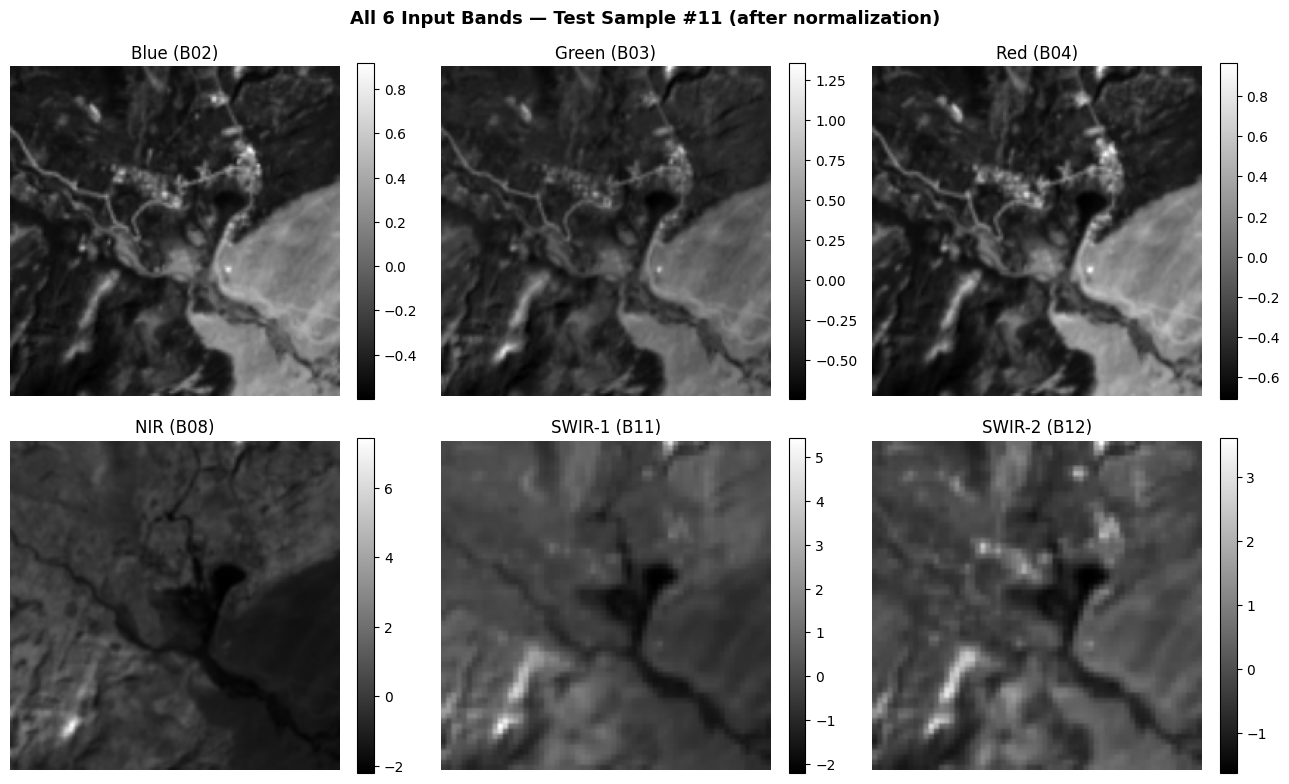

In [58]:
# ── Visualize all 6 input bands (after normalization) ─────────────────────────
BAND_NAMES = ['Blue (B02)', 'Green (B03)', 'Red (B04)',
              'NIR (B08)',  'SWIR-1 (B11)', 'SWIR-2 (B12)']

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, (arr, name) in enumerate(zip(image, BAND_NAMES)):
    im = axes[i].imshow(arr, cmap='gray')
    axes[i].set_title(name)
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle(f'All 6 Input Bands — Test Sample #{SAMPLE_IDX} (after normalization)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


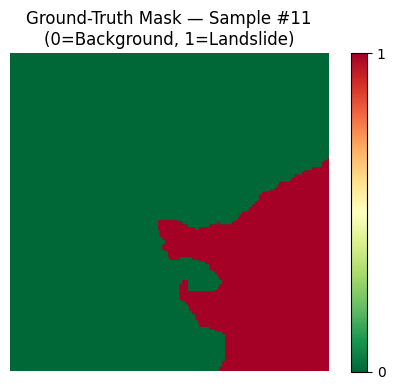

In [59]:
# ── Visualize ground-truth label ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(label, cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_title(f'Ground-Truth Mask — Sample #{SAMPLE_IDX}\n(0=Background, 1=Landslide)')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, ticks=[0, 1])
plt.tight_layout()
plt.show()


In [60]:
# ── Prepare input tensor for inference ────────────────────────────────────────
# Add batch dimension: (C, T, H, W) -> (1, C, T, H, W)
x_pt = x.unsqueeze(0).float().to(device)
print(f"x_pt.shape : {x_pt.shape}  ->  (Batch=1, C, T, H, W)")


x_pt.shape : torch.Size([1, 6, 1, 224, 224])  ->  (Batch=1, C, T, H, W)


In [61]:
# ── Forward pass ──────────────────────────────────────────────────────────────
with torch.no_grad():
    result = model(x_pt)

# result.output shape: (1, num_classes=2, H=224, W=224)
print(f"result.output.shape : {result.output.shape}  ->  (Batch, Classes, H, W)")


result.output.shape : torch.Size([1, 2, 224, 224])  ->  (Batch, Classes, H, W)


In [62]:
# ── Argmax over class dimension -> predicted class map ────────────────────────
# softmax converts logits to probabilities, argmax picks the highest-prob class
_, pred_pt = torch.max(nn.functional.softmax(result.output, dim=1).detach(), dim=1)
print(f"pred_pt.shape : {pred_pt.shape}  ->  (Batch=1, H=224, W=224)")


pred_pt.shape : torch.Size([1, 224, 224])  ->  (Batch=1, H=224, W=224)


In [63]:
# ── Convert prediction to NumPy array ─────────────────────────────────────────
pred = pred_pt.squeeze().cpu().numpy()   # shape: (224, 224)
print(f"pred.shape : {pred.shape}  ->  (H, W)")
print(f"Unique predicted classes : {np.unique(pred)}  (0=background, 1=landslide)")


pred.shape : (224, 224)  ->  (H, W)
Unique predicted classes : [0 1]  (0=background, 1=landslide)


### 🗺️ Ground-Truth vs. Predicted Mask Comparison
Compare the ground-truth label and the model's predicted mask side-by-side.
Differences highlight where the model succeeds and where it struggles.

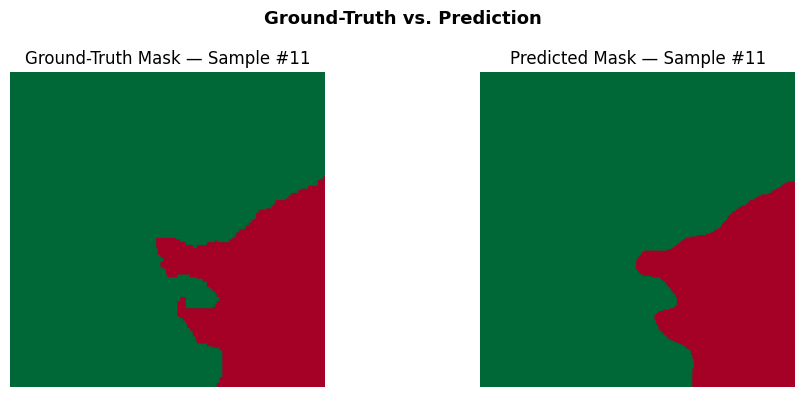

In [64]:
# ── Side-by-side: Ground-Truth vs. Predicted Mask ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(label, cmap='RdYlGn_r', vmin=0, vmax=1)
axes[0].set_title(f'Ground-Truth Mask — Sample #{SAMPLE_IDX}')
axes[0].axis('off')

axes[1].imshow(pred, cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1].set_title(f'Predicted Mask — Sample #{SAMPLE_IDX}')
axes[1].axis('off')

plt.suptitle('Ground-Truth vs. Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 🔴🟢🔵 Error Map: TP / FP / FN Overlay
Compute a pixel-level confusion map and visualize it as a color overlay.
This gives immediate visual feedback on where the model makes errors.

In [65]:
# ── Compute pixel-level TP / FP / TN / FN ────────────────────────────────────
tp = np.logical_and(label == 1, pred == 1)   # Correctly detected landslide
fp = np.logical_and(label == 0, pred == 1)   # Background predicted as landslide
tn = np.logical_and(label == 0, pred == 0)   # Correctly detected background
fn = np.logical_and(label == 1, pred == 0)   # Landslide missed by model

print(f"TP : {tp.sum():>5d} pixels  (correctly detected landslide)")
print(f"FP : {fp.sum():>5d} pixels  (false alarm)")
print(f"TN : {tn.sum():>5d} pixels  (correctly detected background)")
print(f"FN : {fn.sum():>5d} pixels  (missed landslide)")

# Derived metrics for this sample
precision = tp.sum() / (tp.sum() + fp.sum() + 1e-7)
recall    = tp.sum() / (tp.sum() + fn.sum() + 1e-7)
iou       = tp.sum() / (tp.sum() + fp.sum() + fn.sum() + 1e-7)
print(f"\nSample-level metrics:")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  IoU       : {iou:.4f}")


TP : 10732 pixels  (correctly detected landslide)
FP :   252 pixels  (false alarm)
TN : 38645 pixels  (correctly detected background)
FN :   547 pixels  (missed landslide)

Sample-level metrics:
  Precision : 0.9771
  Recall    : 0.9515
  IoU       : 0.9307


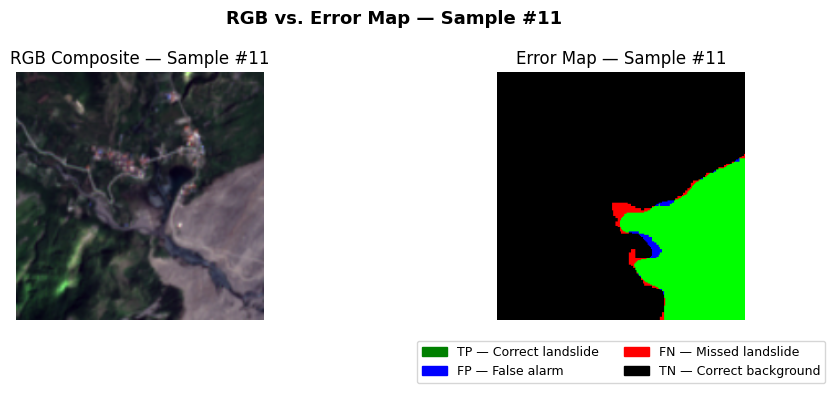

In [66]:
# ── Color-coded error overlay ─────────────────────────────────────────────────
# Pixel color encodes confusion matrix outcome:
#   Black = TN  (background correctly classified)
#   Green = TP  (landslide correctly detected)
#   Blue  = FP  (background misclassified as landslide — false alarm)
#   Red   = FN  (landslide missed — false negative)
H, W = label.shape
error_rgb = np.zeros((H, W, 3), dtype=np.float32)
error_rgb[tp] = [0, 1, 0]   # TP → Green
error_rgb[fp] = [0, 0, 1]   # FP → Blue
error_rgb[fn] = [1, 0, 0]   # FN → Red

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# RGB composite for spatial context (bands: Red=B04, Green=B03, Blue=B02)
arr_rgb_norm = np.dstack((image[2], image[1], image[0]))
arr_rgb_norm = (arr_rgb_norm - arr_rgb_norm.min()) / (arr_rgb_norm.max() - arr_rgb_norm.min() + 1e-7)
axes[0].imshow(arr_rgb_norm)
axes[0].set_title(f'RGB Composite — Sample #{SAMPLE_IDX}')
axes[0].axis('off')

axes[1].imshow(error_rgb)
axes[1].set_title(f'Error Map — Sample #{SAMPLE_IDX}')
axes[1].axis('off')

legend_elements = [
    mpatches.Rectangle((0,0), 1, 1, color='g', label='TP — Correct landslide'),
    mpatches.Rectangle((0,0), 1, 1, color='b', label='FP — False alarm'),
    mpatches.Rectangle((0,0), 1, 1, color='r', label='FN — Missed landslide'),
    mpatches.Rectangle((0,0), 1, 1, color='k', label='TN — Correct background'),
]
axes[1].legend(handles=legend_elements, loc='upper center',
               ncol=2, bbox_to_anchor=(0.5, -0.06), fontsize=9)

plt.suptitle(f'RGB vs. Error Map — Sample #{SAMPLE_IDX}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 14. Multi-Sample Result Visualization

### 🎯 Objective
Visualize model predictions across multiple test samples in a single grid.
This provides a broader view of model performance beyond a single patch.

### Grid Layout (per sample row)
```
RGB Composite | Ground-Truth Mask | Predicted Mask | Error Map
```


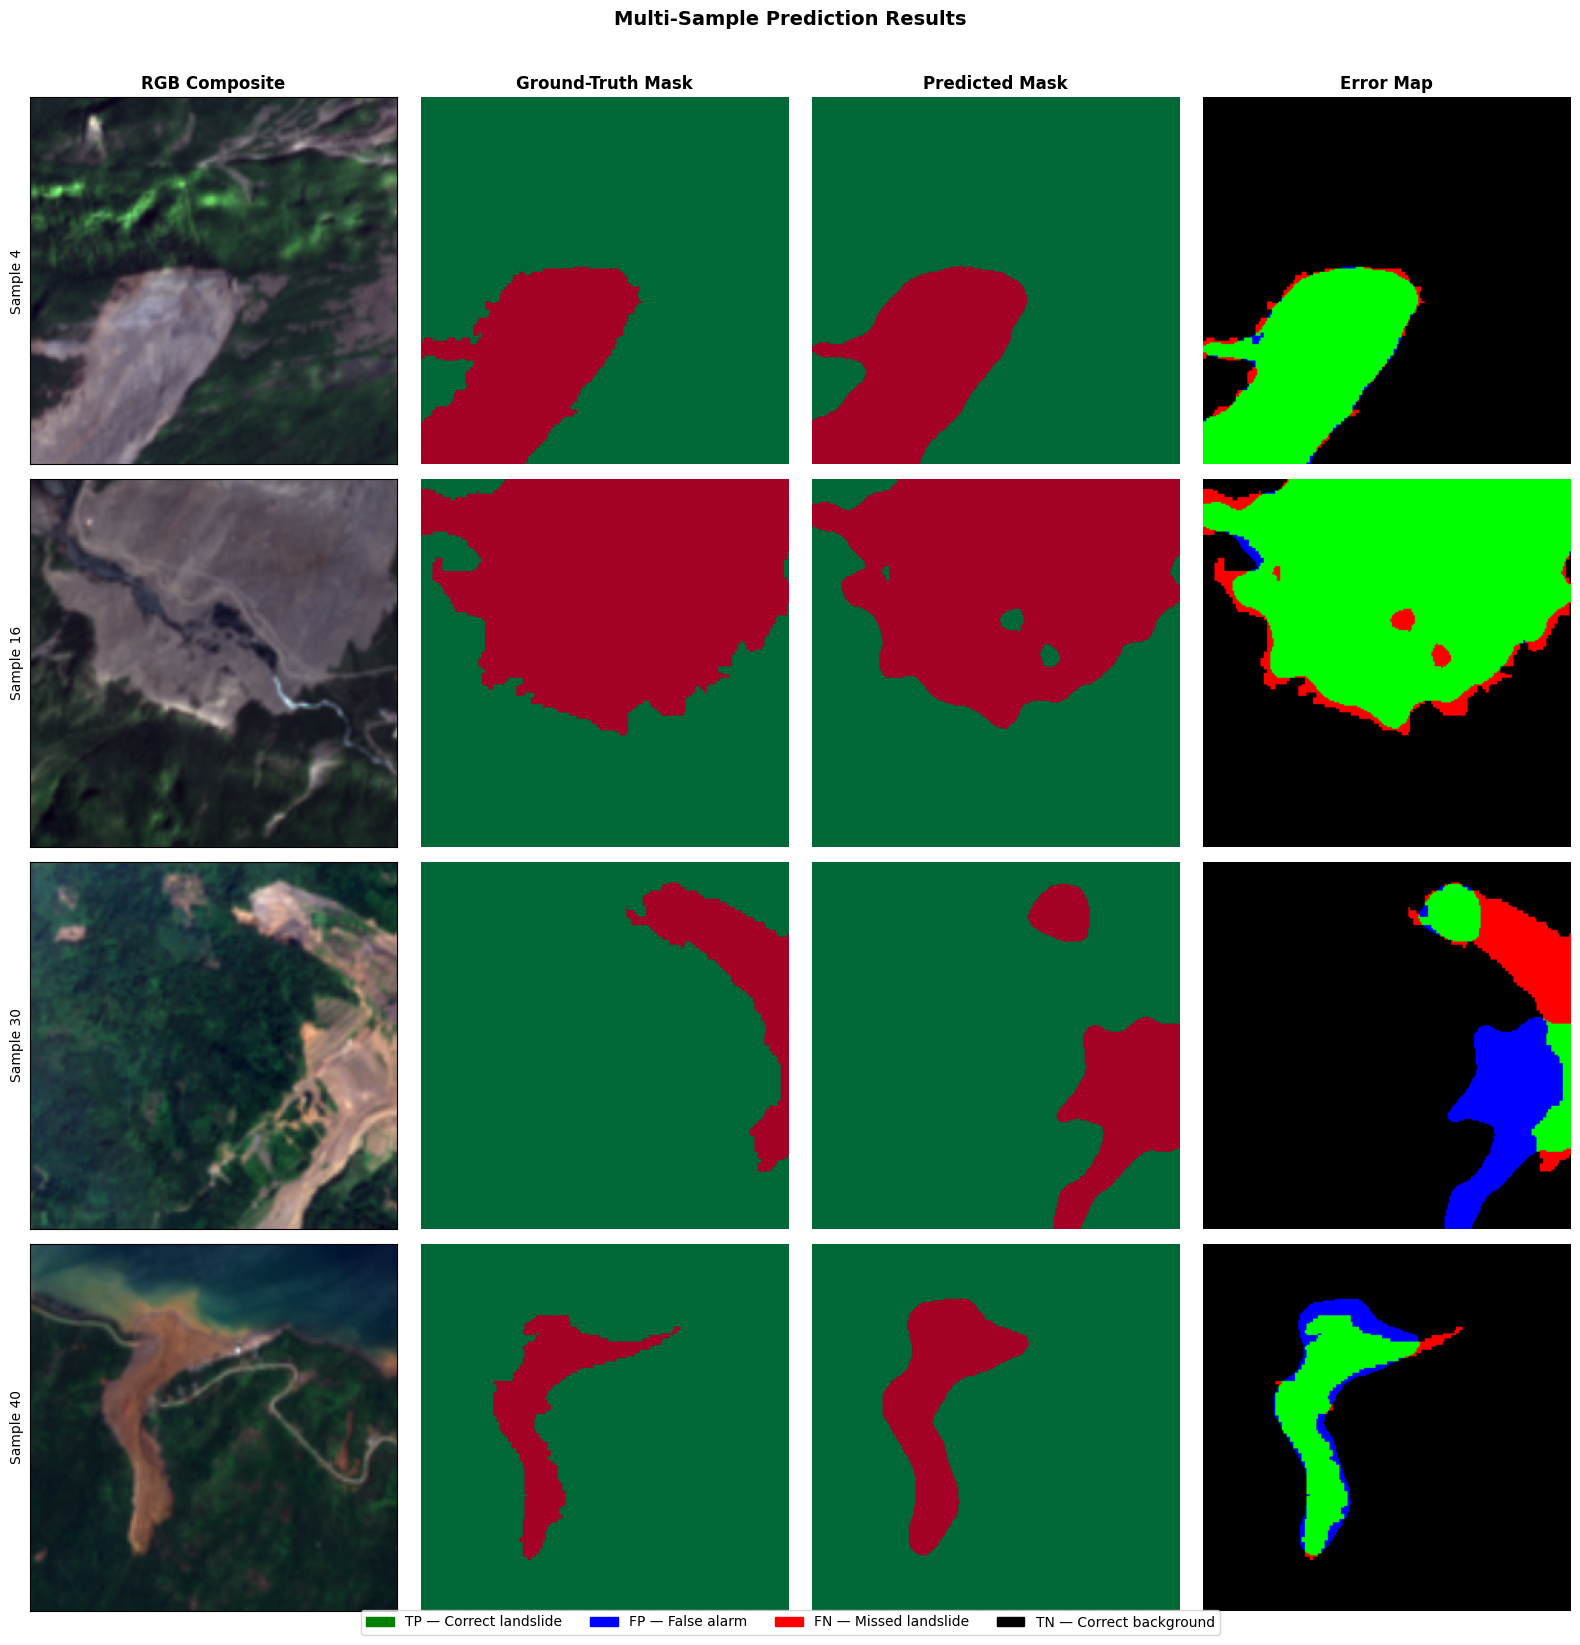

In [67]:
# ── Visualize predictions for multiple test samples in a grid ─────────────────
# Each row: RGB Composite | Ground-Truth Mask | Predicted Mask | Error Map
N_SHOW  = 4
INDICES = [4, 16, 30, 40]   # ← change these indices to explore other patches

fig, axes = plt.subplots(N_SHOW, 4, figsize=(16, 4 * N_SHOW))
col_titles = ['RGB Composite', 'Ground-Truth Mask', 'Predicted Mask', 'Error Map']

for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=12, fontweight='bold')

for row, idx in enumerate(INDICES):
    x_i, y_i = test_dataset[idx]

    # Prepare arrays
    img_i   = x_i.squeeze(1).numpy()   # (C, H, W)
    label_i = y_i.numpy()              # (H, W)

    # Forward pass
    x_pt_i = x_i.unsqueeze(0).float().to(device)
    with torch.no_grad():
        res_i = model(x_pt_i)
    _, pred_pt_i = torch.max(
        nn.functional.softmax(res_i.output, dim=1).detach(), dim=1
    )
    pred_i = pred_pt_i.squeeze().cpu().numpy()   # (H, W)

    # ── Col 0: RGB composite ───────────────────────────────────────────
    rgb_i = np.dstack((img_i[2], img_i[1], img_i[0]))
    rgb_i = (rgb_i - rgb_i.min()) / (rgb_i.max() - rgb_i.min() + 1e-7)
    axes[row][0].imshow(rgb_i)
    axes[row][0].set_ylabel(f'Sample {idx}', fontsize=10, labelpad=4)
    axes[row][0].tick_params(left=False, bottom=False,
                             labelleft=False, labelbottom=False)

    # ── Col 1: Ground-truth mask ───────────────────────────────────────
    axes[row][1].imshow(label_i, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[row][1].axis('off')

    # ── Col 2: Predicted mask ──────────────────────────────────────────
    axes[row][2].imshow(pred_i, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[row][2].axis('off')

    # ── Col 3: Error map ───────────────────────────────────────────────
    H_i, W_i = label_i.shape
    err_rgb_i = np.zeros((H_i, W_i, 3), dtype=np.float32)
    err_rgb_i[np.logical_and(label_i == 1, pred_i == 1)] = [0, 1, 0]  # TP
    err_rgb_i[np.logical_and(label_i == 0, pred_i == 1)] = [0, 0, 1]  # FP
    err_rgb_i[np.logical_and(label_i == 1, pred_i == 0)] = [1, 0, 0]  # FN
    axes[row][3].imshow(err_rgb_i)
    axes[row][3].axis('off')

# Shared legend below figure
legend_elements = [
    mpatches.Rectangle((0,0), 1, 1, color='g', label='TP — Correct landslide'),
    mpatches.Rectangle((0,0), 1, 1, color='b', label='FP — False alarm'),
    mpatches.Rectangle((0,0), 1, 1, color='r', label='FN — Missed landslide'),
    mpatches.Rectangle((0,0), 1, 1, color='k', label='TN — Correct background'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.suptitle('Multi-Sample Prediction Results', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 🏁 Workshop Wrap-up & Next Steps

### What We Learned Today
1. **HDF5 satellite data** exploration and multi-band visualization
2. **Custom PyTorch Dataset** implementation for segmentation
3. **Per-channel normalization** statistics computation 
4. **Data augmentation** (random flip & rotate)
5. **Foundation model fine-tuning** — Prithvi ViT encoder + UNet decoder via TerraTorch
6. **Dice Loss**-based training loop with best-checkpoint saving
7. **TP/FP/TN/FN-based** segmentation metrics (Precision, Recall, F1, IoU)
8. **Test set evaluation** and single/multi-sample prediction visualization

### 🚀 Going Further
- **Multi-temporal data**: Use both pre-event and post-event images together (`num_frames=2`)
- **Add SAR channels**: Fuse Sentinel-1 bands with Sentinel-2 for all-weather detection

### References
- [Prithvi-EO-2.0 HuggingFace](https://huggingface.co/ibm-nasa-geospatial)
- [TerraTorch GitHub](https://github.com/terrastackai/terratorch)
- [Getting Started with PyTorch](https://docs.pytorch.org/tutorials/beginner/basics/intro.html)
- [Sentinel-2](https://sentiwiki.copernicus.eu/web/sentinel-2)
- [Orynbaikyzy et al. (2025). *Landslide mapping with deep learning: the role of pre-/post-event SAR features and multi-sensor data fusion.* GIScience & Remote Sensing, 62(1).](https://www.tandfonline.com/doi/full/10.1080/15481603.2025.2502214)
    * [Landslide Reference Dataset](https://zenodo.org/records/17007637)

In [68]:
# end of document
